In [1]:
from pathlib import Path
import pandas as pd

# Deterministically resolve project root independent of caller working directory
current_dir = Path.cwd().resolve()
if (current_dir / "src" / "transformers.py").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "src" / "transformers.py").exists():
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = next(
        (p for p in [current_dir] + list(current_dir.parents) if (p / "src" / "transformers.py").exists() or (p / "data" / "raw" / "bank-additional-full.csv").exists()),
        current_dir
    )

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bank-additional-full.csv"

# Locate dataset dynamically with fallback candidate paths
if not RAW_DATA_PATH.exists():
    candidates = [
        RAW_DATA_PATH,
        Path("../data/raw/bank-additional-full.csv"),
        Path("data/raw/bank-additional-full.csv"),
        Path("bank-additional-full.csv"),
        Path("../../data/raw/bank-additional-full.csv")
    ]
    for p in candidates:
        if p.exists():
            RAW_DATA_PATH = p.resolve()
            break

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Could not locate 'bank-additional-full.csv' at {RAW_DATA_PATH} or candidate directories.")

df = pd.read_csv(
    RAW_DATA_PATH,
    sep=";"
)

df.head()

In [2]:
df.shape

In [3]:
df.columns

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

### Dataset Overview

The Bank Marketing dataset contains 41,188 customer campaign records and 21 attributes. Each record represents a customer contact during a marketing campaign.

The dataset includes customer demographic information, financial information, campaign-related details, and economic indicators. The target variable is `y`, which represents whether the customer subscribed to the term deposit (`yes` or `no`).

The dataset contains both numerical and categorical variables. No missing/null values were identified during the initial data quality check.

In [5]:
df.head()

In [6]:
df.isnull().sum()

In [7]:
df.isnull().sum().sum()

In [8]:
for col in df.columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(col, unknown_count)

job 330
marital 80
education 1731
default 8597
housing 990
loan 990


In [9]:
for col in df.columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        percentage = (unknown_count / len(df)) * 100
        print(col, round(percentage,2), "%")

job 0.8 %
marital 0.19 %
education 4.2 %
default 20.87 %
housing 2.4 %
loan 2.4 %


### Unknown Value Analysis

Although the dataset does not contain traditional missing values (null values), several categorical variables contain the value "unknown", which represents unavailable customer information.

The distribution of unknown values was analyzed to understand data quality issues.

The highest number of unknown values appears in the `default` feature (8,597 records), followed by `education` (1,731 records). Other variables such as `housing`, `loan`, `job`, and `marital` contain fewer unknown values.

These unknown values should not be removed immediately because they may contain useful information. The handling strategy will be decided during the preprocessing stage based on their impact on model performance.

In [10]:
df['y'].value_counts()

In [11]:
df['y'].value_counts(normalize=True)*100

## Target Variable Analysis

The target variable `y` represents whether a customer subscribed to the bank's term deposit after the marketing campaign.

- `yes` indicates successful subscription.
- `no` indicates that the customer did not subscribe.

The analysis shows that out of 41,188 customer records, 36,548 customers did not subscribe, while only 4,640 customers subscribed.

The target variable is highly imbalanced, with 88.73% of records belonging to the `no` class and only 11.27% belonging to the `yes` class.

This class imbalance is an important consideration for model development because a model may achieve high accuracy by mainly predicting the majority class. Therefore, evaluation should consider additional metrics such as precision, recall, F1-score, ROC-AUC, and PR-AUC.

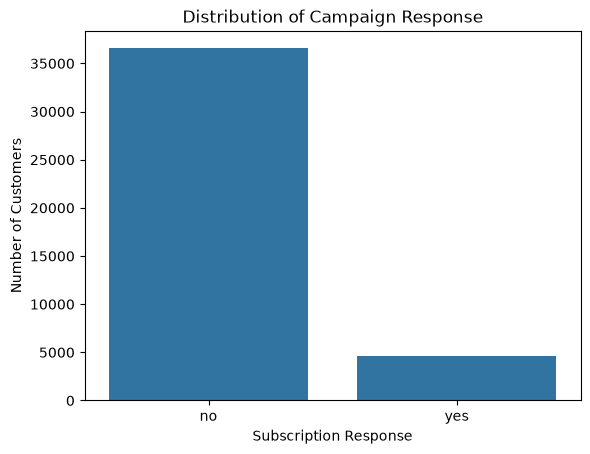

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='y')

plt.title("Distribution of Campaign Response")
plt.xlabel("Subscription Response")
plt.ylabel("Number of Customers")

plt.show()

In [13]:
df.describe()

Numerical Feature Summary
The descriptive statistics provide an overview of the numerical variables in the Bank Marketing dataset, including their distribution, central tendency, and range.

The dataset contains 41,188 records, and all numerical variables have complete observations.

Key observations:

The average customer age is approximately 40 years, with ages ranging from 17 to 98 years.
The duration feature has a wide range, from 0 to 4918 seconds, indicating high variation in call durations and possible outliers.
The campaign feature shows that customers were contacted an average of approximately 2–3 times during the current campaign, although some customers received many contacts.
The pdays feature contains many values of 999, which represents customers who were not previously contacted.
The previous feature indicates that most customers had limited previous campaign interactions.
Economic variables such as emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, and nr.employed provide information about the economic conditions during the campaign period.


---

# 3. Exploratory Data Analysis by Feature Family & Target Relationships

To establish an evidence-based foundation for subsequent preprocessing pipelines and model architectures, exploratory data analysis must move beyond disconnected univariate distributions. In telemarketing response prediction, predictors operate within distinct operational, demographic, and macro-financial contexts.

In accordance with project guidelines, this section systematically analyzes the four major predictor families:
1. **Customer Profile Variables**: Demographics (`age`, `job`, `marital`, `education`) and financial commitments (`default`, `housing`, `loan`).
2. **Current Campaign Operational Variables**: Communication channel (`contact`), temporal placement (`month`, `day_of_week`), and contact intensity (`campaign`).
3. **Historical Campaign Context Variables**: Prior contact volume (`previous`), recency (`pdays`), and past campaign outcome (`poutcome`).
4. **Macroeconomic Climate Indicators**: Employment variation (`emp.var.rate`), price indices (`cons.price.idx`, `cons.conf.idx`), benchmark interest rate (`euribor3m`), and labor force volume (`nr.employed`).

To avoid redundant, low-value visual plots, analyses are grouped into multi-panel comparative figures. Each feature family addresses four fundamental analytical questions:
- **What pattern exists?** (Underlying distributions, frequencies, and spread)
- **Does it relate to the target?** (Response rate contrasts against the 11.27% dataset baseline)
- **Why does it matter?** (Behavioral, financial, or operational domain mechanisms)
- **Does it affect preprocessing/feature engineering/model evaluation?** (Direct architectural implications)

### 3.1 Customer Profile Variables (Demographics & Financial Standing)

Customer profile variables capture the personal life stage, socio-economic stratum, and debt obligations of prospective clients. We examine whether personal attributes govern a customer's propensity to lock funds into a long-term savings instrument.

In [14]:
# 1. Stratified Quantitative Analysis of Age by Campaign Response
age_stats = df.groupby('y')['age'].describe()
print("=== Numerical Distribution of Age Stratified by Subscription Response ===")
print(age_stats.round(2))

# 2. Conversion Rate across Life-Stage Age Cohorts
df['age_cohort'] = pd.cut(
    df['age'],
    bins=[0, 25, 30, 40, 50, 60, 120],
    labels=['<25 (Young Adult)', '25-29 (Early Career)', '30-39 (Family Formation)', '40-49 (Mid Career)', '50-59 (Pre-Retirement)', '60+ (Senior/Retiree)'],
    right=False
)
age_cohort_ct = pd.crosstab(df['age_cohort'], df['y'], normalize='index') * 100
age_cohort_ct['Total Records'] = df['age_cohort'].value_counts()
print("\n=== Conversion Rate and Sample Count across Life-Stage Age Cohorts ===")
print(age_cohort_ct[['Total Records', 'no', 'yes']].round(2))

# 3. Categorical Customer Variables Response Rates
cat_customer = ['job', 'marital', 'education', 'default', 'housing', 'loan']
print("\n=== Response Rates for Categorical Customer Variables (% yes) ===")
for col in cat_customer:
    ct = pd.crosstab(df[col], df['y'], normalize='index')['yes'] * 100
    counts = df[col].value_counts()
    summary = pd.DataFrame({'Response Rate (%)': ct, 'Count': counts}).sort_values('Response Rate (%)', ascending=False)
    print(f"\n--- {col.upper()} ---")
    print(summary.round(2))

=== Numerical Distribution of Age Stratified by Subscription Response ===
       count   mean    std   min   25%   50%   75%   max
y                                                       
no   36548.0  39.91   9.90  17.0  32.0  38.0  47.0  95.0
yes   4640.0  40.91  13.84  17.0  31.0  37.0  50.0  98.0

=== Conversion Rate and Sample Count across Life-Stage Age Cohorts ===
y                         Total Records     no    yes
age_cohort                                           
<25 (Young Adult)                  1068  76.03  23.97
25-29 (Early Career)               4601  85.52  14.48
30-39 (Family Formation)          16938  89.87  10.13
40-49 (Mid Career)                10526  92.08   7.92
50-59 (Pre-Retirement)             6862  89.84  10.16
60+ (Senior/Retiree)               1193  60.44  39.56

=== Response Rates for Categorical Customer Variables (% yes) ===

--- JOB ---
               Response Rate (%)  Count
job                                    
student                    31.43  

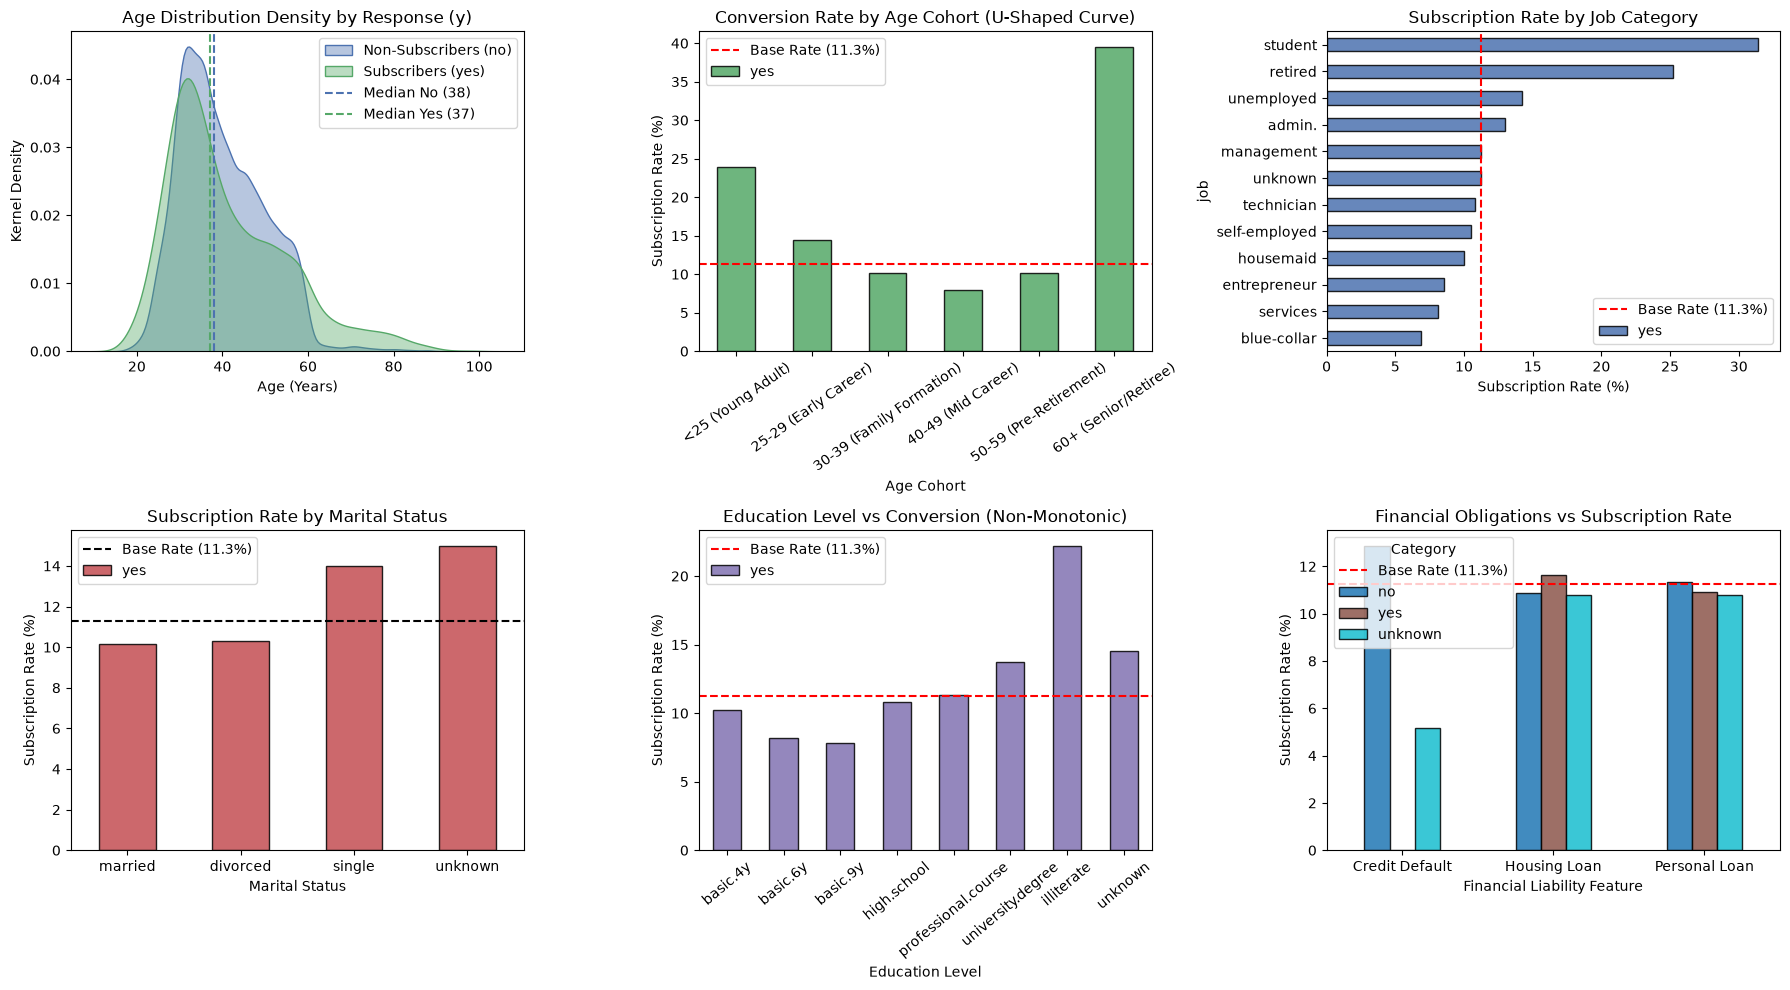

In [15]:
# High-Signal Comparative Visualizations: Customer Profile Variables
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
base_rate = (df['y'] == 'yes').mean() * 100

# 1. Age Distribution by Target (KDE & Median Contrast)
sns.kdeplot(data=df[df['y'] == 'no'], x='age', ax=axes[0, 0], fill=True, color='#4C72B0', label='Non-Subscribers (no)', alpha=0.4)
sns.kdeplot(data=df[df['y'] == 'yes'], x='age', ax=axes[0, 0], fill=True, color='#55A868', label='Subscribers (yes)', alpha=0.4)
axes[0, 0].axvline(df[df['y'] == 'no']['age'].median(), color='#4C72B0', linestyle='--', label=f"Median No ({df[df['y'] == 'no']['age'].median():.0f})")
axes[0, 0].axvline(df[df['y'] == 'yes']['age'].median(), color='#55A868', linestyle='--', label=f"Median Yes ({df[df['y'] == 'yes']['age'].median():.0f})")
axes[0, 0].set_title('Age Distribution Density by Response (y)')
axes[0, 0].set_xlabel('Age (Years)')
axes[0, 0].set_ylabel('Kernel Density')
axes[0, 0].legend(loc='upper right')

# 2. Conversion Rate across Life-Stage Age Cohorts
age_cohort_plot = (pd.crosstab(df['age_cohort'], df['y'], normalize='index')['yes'] * 100)
age_cohort_plot.plot(kind='bar', ax=axes[0, 1], color='#55A868', edgecolor='black', alpha=0.85)
axes[0, 1].axhline(base_rate, color='red', linestyle='--', linewidth=1.5, label=f'Base Rate ({base_rate:.1f}%)')
axes[0, 1].set_title('Conversion Rate by Age Cohort (U-Shaped Curve)')
axes[0, 1].set_ylabel('Subscription Rate (%)')
axes[0, 1].set_xlabel('Age Cohort')
axes[0, 1].tick_params(axis='x', rotation=35)
axes[0, 1].legend()

# 3. Response Rate by Occupation (job)
job_plot = (pd.crosstab(df['job'], df['y'], normalize='index')['yes'] * 100).sort_values()
job_plot.plot(kind='barh', ax=axes[0, 2], color='#4C72B0', edgecolor='black', alpha=0.85)
axes[0, 2].axvline(base_rate, color='red', linestyle='--', linewidth=1.5, label=f'Base Rate ({base_rate:.1f}%)')
axes[0, 2].set_title('Subscription Rate by Job Category')
axes[0, 2].set_xlabel('Subscription Rate (%)')
axes[0, 2].legend(loc='lower right')

# 4. Response Rate by Marital Status
mar_plot = (pd.crosstab(df['marital'], df['y'], normalize='index')['yes'] * 100).sort_values()
mar_plot.plot(kind='bar', ax=axes[1, 0], color='#C44E52', edgecolor='black', alpha=0.85)
axes[1, 0].axhline(base_rate, color='black', linestyle='--', linewidth=1.5, label=f'Base Rate ({base_rate:.1f}%)')
axes[1, 0].set_title('Subscription Rate by Marital Status')
axes[1, 0].set_ylabel('Subscription Rate (%)')
axes[1, 0].set_xlabel('Marital Status')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].legend()

# 5. Education Attainment Response Profile
edu_hierarchy = ['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'professional.course', 'university.degree', 'illiterate', 'unknown']
edu_plot = (pd.crosstab(df['education'], df['y'], normalize='index')['yes'] * 100).reindex(edu_hierarchy)
edu_plot.plot(kind='bar', ax=axes[1, 1], color='#8172B2', edgecolor='black', alpha=0.85)
axes[1, 1].axhline(base_rate, color='red', linestyle='--', linewidth=1.5, label=f'Base Rate ({base_rate:.1f}%)')
axes[1, 1].set_title('Education Level vs Conversion (Non-Monotonic)')
axes[1, 1].set_ylabel('Subscription Rate (%)')
axes[1, 1].set_xlabel('Education Level')
axes[1, 1].tick_params(axis='x', rotation=40)
axes[1, 1].legend()

# 6. Financial Obligations Contrast (default, housing, loan)
fin_summary = pd.DataFrame({
    'no': [
        (df[df['default'] == 'no']['y'] == 'yes').mean() * 100,
        (df[df['housing'] == 'no']['y'] == 'yes').mean() * 100,
        (df[df['loan'] == 'no']['y'] == 'yes').mean() * 100
    ],
    'yes': [
        (df[df['default'] == 'yes']['y'] == 'yes').mean() * 100 if (df['default'] == 'yes').sum() > 0 else 0,
        (df[df['housing'] == 'yes']['y'] == 'yes').mean() * 100,
        (df[df['loan'] == 'yes']['y'] == 'yes').mean() * 100
    ],
    'unknown': [
        (df[df['default'] == 'unknown']['y'] == 'yes').mean() * 100,
        (df[df['housing'] == 'unknown']['y'] == 'yes').mean() * 100,
        (df[df['loan'] == 'unknown']['y'] == 'yes').mean() * 100
    ]
}, index=['Credit Default', 'Housing Loan', 'Personal Loan'])
fin_summary.plot(kind='bar', ax=axes[1, 2], colormap='tab10', edgecolor='black', alpha=0.85)
axes[1, 2].axhline(base_rate, color='red', linestyle='--', linewidth=1.5, label=f'Base Rate ({base_rate:.1f}%)')
axes[1, 2].set_title('Financial Obligations vs Subscription Rate')
axes[1, 2].set_ylabel('Subscription Rate (%)')
axes[1, 2].set_xlabel('Financial Liability Feature')
axes[1, 2].tick_params(axis='x', rotation=0)
axes[1, 2].legend(title='Category')

plt.tight_layout()
plt.show()

#### Findings & Modelling / Preprocessing Implications: Customer Profile Variables

| Dimension | Analytical Finding & Evidence |
| :--- | :--- |
| **What pattern exists?** | 1. **Age Bimodal U-Shape**: While overall central tendencies are deceptively identical (median age $38.0$ for non-subscribers vs $37.0$ for subscribers), the variance for subscribers is $40\%$ wider ($\sigma=13.84$ vs $9.90$). Clients under 25 achieve a **$23.97\%$** conversion rate, and seniors aged 60+ achieve a **$39.56\%$** conversion rate. Conversely, prime working-age individuals (40–49) hit a trough of only **$7.92\%$**.<br>2. **Occupation Disparities**: Non-labor-force participants demonstrate the highest conversion: `student` ($31.43\%$) and `retired` ($25.23\%$). Salaried professionals convert near baseline (`admin.`: $12.97\%$, `technician`: $10.82\%$, `management`: $11.22\%$), whereas `blue-collar` workers convert at only $6.89\%$.<br>3. **Marital Disparities**: `single` clients convert at **$14.00\%$**, significantly outperforming `married` ($10.16\%$) and `divorced` ($10.32\%$) individuals.<br>4. **Education Non-Monotonicity**: Attainment exhibits a distinctly non-monotonic conversion profile: `illiterate` ($22.22\%$) and `university.degree` ($13.72\%$) outperform intermediate tiers (`basic.9y` at $7.82\%$ and `basic.6y` at $8.20\%$). Clients with `unknown` education convert at $14.50\%$.<br>5. **Loan Independence & Default Sparsity**: `housing` loans ($11.62\%$ yes vs $10.88\%$ no) and `loan` personal liabilities ($10.93\%$ yes vs $11.34\%$ no) exhibit near-identical response rates close to baseline ($11.27\%$). `default='yes'` possesses only 3 records (zero conversions), while `default='unknown'` converts at only $5.15\%$ vs $12.88\%$ for `default='no'`. |
| **Does it relate to the target?** | Strong, statistically significant non-linear relationships exist for `age`, `job`, `marital`, and `education`. In contrast, `housing` and `loan` exhibit near-zero marginal association with the target. `default` acts not as a tri-level credit risk metric, but as an information-availability proxy (verified clean credit vs missing records). |
| **Why does it matter?** | **Financial Psychology of Term Deposits**: A term deposit is a low-risk, illiquid savings vehicle requiring capital lockup for a fixed duration. Demographic segments with discretionary liquid savings and low short-term financial commitments—such as retirees seeking capital preservation and students/unmarried individuals with minimal liabilities—naturally exhibit higher demand. In contrast, mid-career family heads (ages 35–50, married, with dependents) have higher routine consumption commitments and lower unallocated cash balances. Existing retail debt (`housing` or `personal loan`) does not suppress term deposit appetite because borrowers and savers frequently coexist within the same retail banking customer segments. |
| **Does it affect preprocessing/feature engineering/model evaluation?** | 1. **Feature Engineering**: Validates the creation of demographic life-stage cohorts (`age_group`: `<30`, `30-39`, `40-49`, `50-59`, `60+`) in `src.transformers.BankFeatureEngineer`. Categorical binning enables linear models (Logistic Regression) to assign distinct positive coefficients to youth and retirement tiers without being constrained by a single linear slope.<br>2. **Categorical Encoding**: Reaffirms **ADR-002**: `education` must be One-Hot Encoded rather than mapped to an ordinal integer hierarchy ($0$ to $7$). Forcing ordinal ranking incorrectly penalizes `illiterate` and `unknown` categories and imposes invalid equal spacing. All nominal variables (`job`, `marital`, `default`, `housing`, `loan`) require One-Hot Encoding with `handle_unknown='ignore'`.<br>3. **Scaling**: Continuous `age` should be standardized using `StandardScaler` to maintain numerical stability during gradient-based optimization.<br>4. **Modelling & Evaluation**: Linear models will require the binned `age_group` features to capture age non-linearities, whereas tree ensembles (Random Forest, Gradient Boosting) can partition continuous age directly. |

### 3.2 Current Campaign Operational Variables

Current campaign variables (`contact`, `month`, `day_of_week`, `campaign`) reflect the telemarketing campaign's execution parameters—specifically how, when, and how frequently the bank reached out to each client during the active campaign.

In [16]:
# 1. Quantitative Analysis of Communication Channel (contact)
contact_ct = pd.crosstab(df['contact'], df['y'], normalize='index') * 100
contact_ct['Call Count'] = df['contact'].value_counts()
print("=== Communication Channel (contact) Performance ===")
print(contact_ct[['Call Count', 'no', 'yes']].round(2))

# 2. Monthly Campaign Dynamics (Volume vs Conversion)
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_ct = pd.crosstab(df['month'], df['y'], normalize='index') * 100
month_ct['Call Volume'] = df['month'].value_counts()
month_ct['Volume Share (%)'] = (month_ct['Call Volume'] / len(df)) * 100
print("\n=== Monthly Campaign Dynamics across Calendar Months ===")
print(month_ct.reindex(month_order)[['Call Volume', 'Volume Share (%)', 'no', 'yes']].round(2))

# 3. Day of Week Conversion Rates
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']
day_ct = pd.crosstab(df['day_of_week'], df['y'], normalize='index') * 100
day_ct['Call Count'] = df['day_of_week'].value_counts()
print("\n=== Day of Week Operational Conversion Rates ===")
print(day_ct.reindex(day_order)[['Call Count', 'no', 'yes']].round(2))

# 4. Contact Fatigue Analysis (campaign call frequency)
df['campaign_tier'] = pd.cut(
    df['campaign'],
    bins=[0, 1, 2, 3, 4, 6, 10, 60],
    labels=['1 contact', '2 contacts', '3 contacts', '4 contacts', '5-6 contacts', '7-10 contacts', '>10 contacts']
)
camp_fatigue = pd.crosstab(df['campaign_tier'], df['y'], normalize='index') * 100
camp_fatigue['Records'] = df['campaign_tier'].value_counts()
print("\n=== Contact Fatigue: Current Campaign Contact Count vs Conversion Rate ===")
print(camp_fatigue[['Records', 'no', 'yes']].round(2))

=== Communication Channel (contact) Performance ===
y          Call Count     no    yes
contact                            
cellular        26144  85.26  14.74
telephone       15044  94.77   5.23

=== Monthly Campaign Dynamics across Calendar Months ===
y      Call Volume  Volume Share (%)     no    yes
month                                             
mar            546              1.33  49.45  50.55
apr           2632              6.39  79.52  20.48
may          13769             33.43  93.57   6.43
jun           5318             12.91  89.49  10.51
jul           7174             17.42  90.95   9.05
aug           6178             15.00  89.40  10.60
sep            570              1.38  55.09  44.91
oct            718              1.74  56.13  43.87
nov           4101              9.96  89.86  10.14
dec            182              0.44  51.10  48.90

=== Day of Week Operational Conversion Rates ===
y            Call Count     no    yes
day_of_week                          
mon     

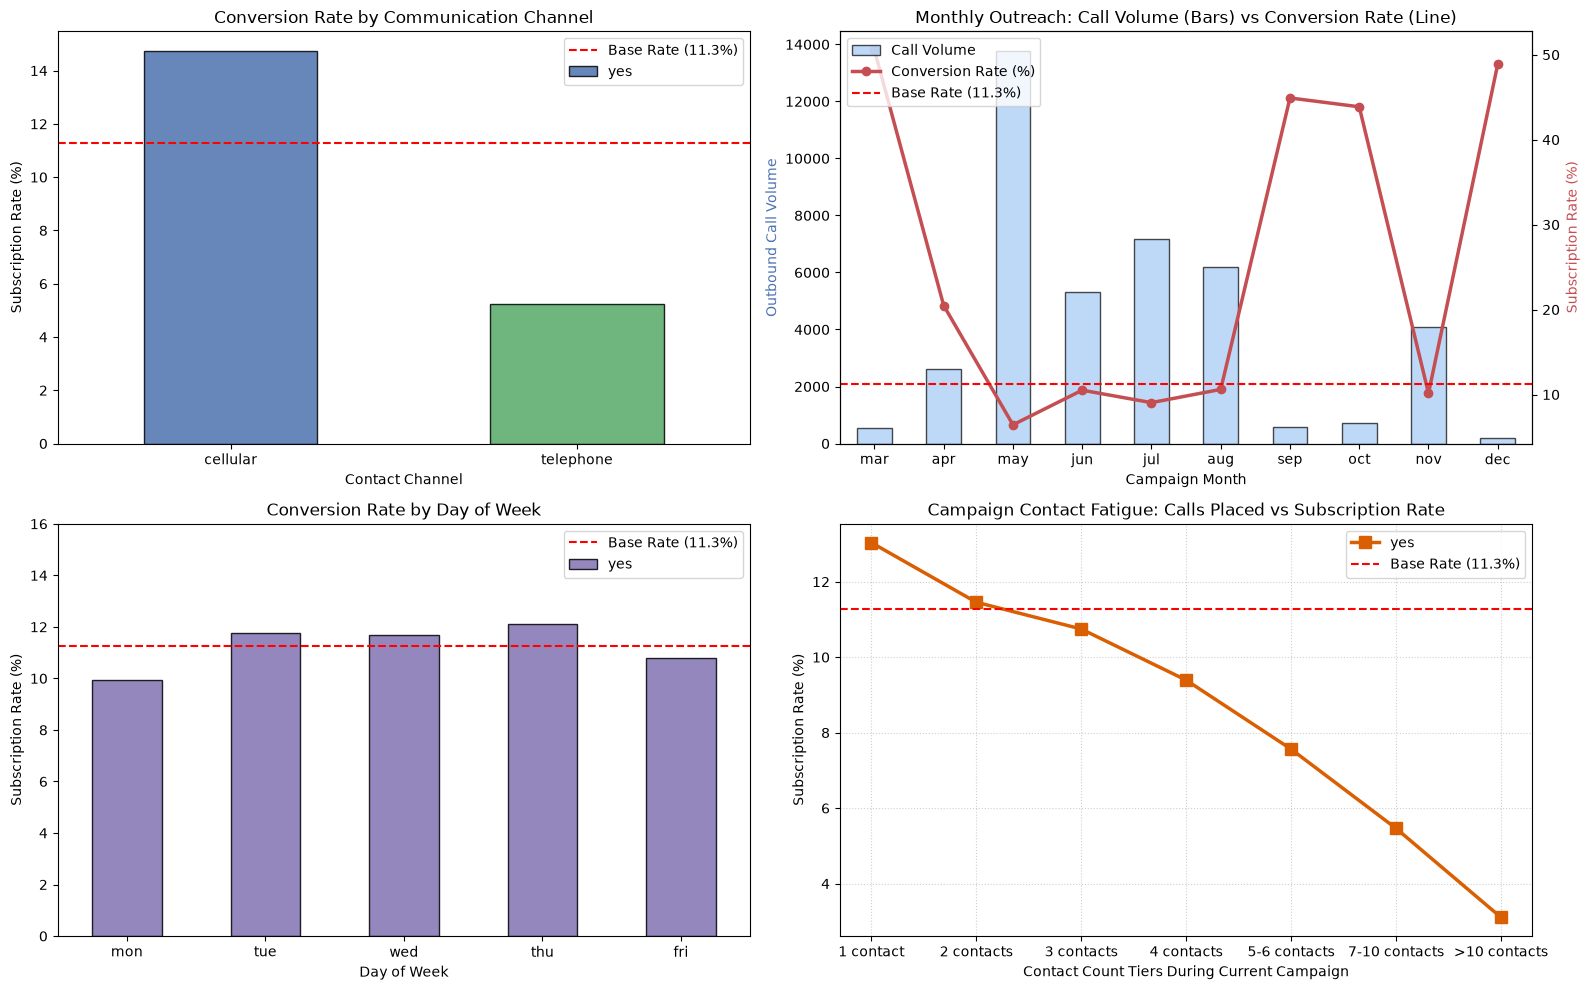

In [17]:
# High-Signal Comparative Visualizations: Campaign Operational Variables
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Communication Channel Conversion
contact_plot = (pd.crosstab(df['contact'], df['y'], normalize='index')['yes'] * 100)
contact_plot.plot(kind='bar', ax=axes[0, 0], color=['#4C72B0', '#55A868'], edgecolor='black', alpha=0.85)
axes[0, 0].axhline(base_rate, color='red', linestyle='--', linewidth=1.5, label=f'Base Rate ({base_rate:.1f}%)')
axes[0, 0].set_title('Conversion Rate by Communication Channel')
axes[0, 0].set_ylabel('Subscription Rate (%)')
axes[0, 0].set_xlabel('Contact Channel')
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].legend()

# 2. Monthly Campaign Dynamics: Call Volume vs Conversion Rate (Dual Axis)
mon_vol = df['month'].value_counts().reindex(month_order)
mon_rate = (pd.crosstab(df['month'], df['y'], normalize='index')['yes'] * 100).reindex(month_order)

ax_vol = axes[0, 1]
ax_rate = ax_vol.twinx()
mon_vol.plot(kind='bar', ax=ax_vol, color='#A1C9F4', edgecolor='black', alpha=0.7, label='Call Volume')
ax_rate.plot(range(len(month_order)), mon_rate.values, color='#C44E52', marker='o', linewidth=2.5, label='Conversion Rate (%)')
ax_rate.axhline(base_rate, color='red', linestyle='--', linewidth=1.5, label=f'Base Rate ({base_rate:.1f}%)')
ax_vol.set_title('Monthly Outreach: Call Volume (Bars) vs Conversion Rate (Line)')
ax_vol.set_xlabel('Campaign Month')
ax_vol.set_ylabel('Outbound Call Volume', color='#4C72B0')
ax_rate.set_ylabel('Subscription Rate (%)', color='#C44E52')
ax_vol.set_xticklabels(month_order, rotation=0)

# Combine legends for dual axis
lines_vol, labels_vol = ax_vol.get_legend_handles_labels()
lines_rate, labels_rate = ax_rate.get_legend_handles_labels()
ax_rate.legend(lines_vol + lines_rate, labels_vol + labels_rate, loc='upper left')

# 3. Day of Week Conversion Rates
day_plot = (pd.crosstab(df['day_of_week'], df['y'], normalize='index')['yes'] * 100).reindex(day_order)
day_plot.plot(kind='bar', ax=axes[1, 0], color='#8172B2', edgecolor='black', alpha=0.85)
axes[1, 0].axhline(base_rate, color='red', linestyle='--', linewidth=1.5, label=f'Base Rate ({base_rate:.1f}%)')
axes[1, 0].set_title('Conversion Rate by Day of Week')
axes[1, 0].set_ylabel('Subscription Rate (%)')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].set_ylim(0, 16)
axes[1, 0].legend()

# 4. Campaign Contact Fatigue Curve
camp_fatigue_plot = (pd.crosstab(df['campaign_tier'], df['y'], normalize='index')['yes'] * 100)
camp_fatigue_plot.plot(kind='line', ax=axes[1, 1], marker='s', color='#D95F02', linewidth=2.5, markersize=8)
axes[1, 1].axhline(base_rate, color='red', linestyle='--', linewidth=1.5, label=f'Base Rate ({base_rate:.1f}%)')
axes[1, 1].set_title('Campaign Contact Fatigue: Calls Placed vs Subscription Rate')
axes[1, 1].set_xlabel('Contact Count Tiers During Current Campaign')
axes[1, 1].set_ylabel('Subscription Rate (%)')
axes[1, 1].grid(True, linestyle=':', alpha=0.6)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

#### Findings & Modelling / Preprocessing Implications: Campaign Operational Variables

| Dimension | Analytical Finding & Evidence |
| :--- | :--- |
| **What pattern exists?** | 1. **Channel Disparity**: Cellular outreach achieves a **$14.74\%$** conversion rate ($N=26,144$) vs only **$5.23\%$** for landline telephone ($N=15,044$)—a **$2.8\times$ conversion superiority**.<br>2. **Severe Monthly Operational Imbalance**: Outbound calling displays extreme volume and efficiency decoupling. May accounts for a massive **$33.43\%$** of all contacts ($13,769$ calls) but yields the worst conversion rate in the dataset (**$6.43\%$**). In contrast, March ($50.55\%$), September ($44.91\%$), October ($43.87\%$), and December ($48.90\%$) exhibit stellar conversion rates on selective, low-volume campaigns ($<800$ calls each).<br>3. **Day-of-Week Uniformity**: Conversion rates across business days remain tightly bounded between $9.95\%$ (Monday) and $12.12\%$ (Thursday), exhibiting minimal variance.<br>4. **Monotonic Contact Fatigue**: Success probability strictly degrades as calling frequency increases: $1^{\text{st}}$ contact ($13.04\%$), $2^{\text{nd}}$ ($11.46\%$), $3^{\text{rd}}$ ($10.75\%$), $4^{\text{th}}$ ($9.39\%$), $5-6$ contacts ($7.56\%$), $7-10$ contacts ($5.47\%$), and $>10$ contacts ($3.11\%$). |
| **Does it relate to the target?** | `contact`, `month`, and `campaign` contact frequency relate strongly and significantly to campaign response. `day_of_week` has negligible predictive utility and minimal effect size. |
| **Why does it matter?** | 1. **Operational Waste & Call Fatigue**: Contacting an unresponsive prospect more than 3 times generates steep diminishing returns and customer irritation. Over $5,000$ calls were placed to individuals contacted $4+$ times, producing sub-par yields that squander call center capacity.<br>2. **Channel Reachability**: Cellular phones reach prospective clients directly and represent personal communication devices. Fixed landlines are disproportionately answered by gatekeepers or unassisted households.<br>3. **Quarter-End / Tax Seasonality**: High-performing months align with financial milestones (March tax planning, September back-to-work, December year-end bonus allocations). |
| **Does it affect preprocessing/feature engineering/model evaluation?** | 1. **Scaling Choice for `campaign`**: The `campaign` feature exhibits extreme positive skewness ($4.76$) with outliers reaching up to $56$ contacts. Applying `StandardScaler` would be corrupted by extreme outliers; this directly justifies applying `RobustScaler` (median & IQR centering) to `campaign` in the preprocessing pipeline.<br>2. **Categorical Encoding**: `contact`, `month`, and `day_of_week` are nominal and should be One-Hot Encoded with `handle_unknown='ignore'`.<br>3. **Holdout Split Reassurance (ADR-001)**: September is exclusively concentrated between row indices $37,887$ and $40,855$. Chronological partitioning completely starves the training set of `month='sep'`, creating an out-of-vocabulary test anomaly. Stratified random holdout guarantees uniform category coverage across all 10 months.<br>4. **Modelling & Policy**: Model decile lift analysis should be utilized to establish operational call-termination rules (e.g., stopping outreach after 3 attempts if predicted response probability remains low). |

### 3.3 Historical Campaign Context Variables

Historical campaign variables (`previous`, `pdays`, `poutcome`) record the bank's prior outreach history with each client before the current campaign began. They provide critical insight into customer relationship warmth and long-term bank loyalty.

In [18]:
# 1. Conversion Rate Progression by Previous Contact Count (previous)
df['prev_tier'] = df['previous'].apply(lambda x: str(x) if x < 4 else '4+')
prev_ct = pd.crosstab(df['prev_tier'], df['y'], normalize='index') * 100
prev_ct['Records'] = df['prev_tier'].value_counts()
print("=== Prior Contact Count (previous) vs Subscription Rate ===")
print(prev_ct.reindex(['0', '1', '2', '3', '4+'])[['Records', 'no', 'yes']].round(2))

# 2. Conversion Contrast: pdays Sentinel (999) vs Elapsed Contact Recency Cohorts
df['pdays_cohort'] = pd.cut(
    df['pdays'],
    bins=[-1, 3, 6, 14, 998, 1000],
    labels=['0-3 days (Very Recent)', '4-6 days (Recent)', '7-14 days (Moderate)', '15+ days (Older)', 'Not Contacted (pdays=999)'],
    right=True
)
pdays_ct = pd.crosstab(df['pdays_cohort'], df['y'], normalize='index') * 100
pdays_ct['Records'] = df['pdays_cohort'].value_counts()
print("\n=== Contact Recency Windows (pdays) vs Subscription Rate ===")
print(pdays_ct[['Records', 'no', 'yes']].round(2))

# 3. Historical Campaign Outcome (poutcome) Performance
pout_ct = pd.crosstab(df['poutcome'], df['y'], normalize='index') * 100
pout_ct['Records'] = df['poutcome'].value_counts()
print("\n=== Previous Campaign Outcome (poutcome) vs Subscription Rate ===")
print(pout_ct.reindex(['nonexistent', 'failure', 'success'])[['Records', 'no', 'yes']].round(2))

=== Prior Contact Count (previous) vs Subscription Rate ===
y          Records     no    yes
prev_tier                       
0            35563  91.17   8.83
1             4561  78.80  21.20
2              754  53.58  46.42
3              216  40.74  59.26
4+              94  42.55  57.45

=== Contact Recency Windows (pdays) vs Subscription Rate ===
y                          Records     no    yes
pdays_cohort                                    
0-3 days (Very Recent)         541  34.75  65.25
4-6 days (Recent)              576  33.85  66.15
7-14 days (Moderate)           336  41.37  58.63
15+ days (Older)                62  41.94  58.06
Not Contacted (pdays=999)    39673  90.74   9.26

=== Previous Campaign Outcome (poutcome) vs Subscription Rate ===
y            Records     no    yes
poutcome                          
nonexistent    35563  91.17   8.83
failure         4252  85.77  14.23
success         1373  34.89  65.11


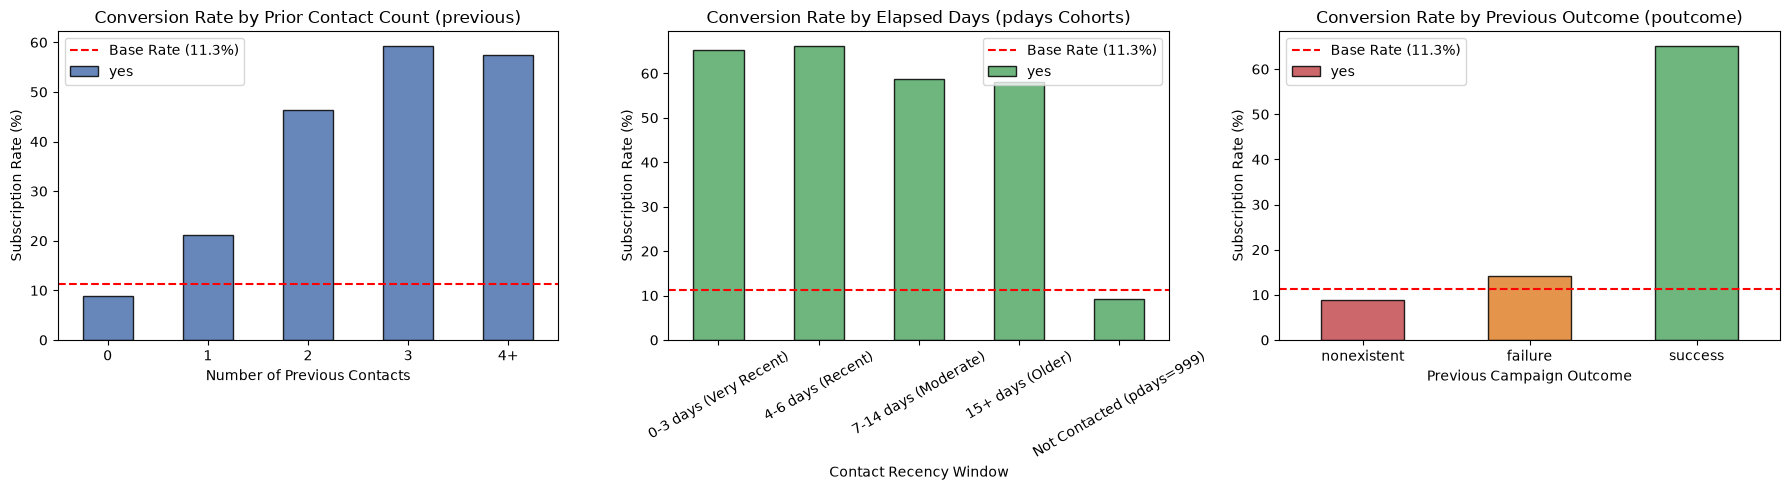

In [19]:
# High-Signal Comparative Visualizations: Historical Campaign Context Variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Prior Contact Count (previous)
prev_plot = (pd.crosstab(df['prev_tier'], df['y'], normalize='index')['yes'] * 100).reindex(['0', '1', '2', '3', '4+'])
prev_plot.plot(kind='bar', ax=axes[0], color='#4C72B0', edgecolor='black', alpha=0.85)
axes[0].axhline(base_rate, color='red', linestyle='--', linewidth=1.5, label=f'Base Rate ({base_rate:.1f}%)')
axes[0].set_title('Conversion Rate by Prior Contact Count (previous)')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].set_xlabel('Number of Previous Contacts')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

# 2. pdays Contact Recency Cohorts
pdays_plot = (pd.crosstab(df['pdays_cohort'], df['y'], normalize='index')['yes'] * 100)
pdays_plot.plot(kind='bar', ax=axes[1], color='#55A868', edgecolor='black', alpha=0.85)
axes[1].axhline(base_rate, color='red', linestyle='--', linewidth=1.5, label=f'Base Rate ({base_rate:.1f}%)')
axes[1].set_title('Conversion Rate by Elapsed Days (pdays Cohorts)')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].set_xlabel('Contact Recency Window')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

# 3. Previous Campaign Outcome (poutcome)
pout_plot = (pd.crosstab(df['poutcome'], df['y'], normalize='index')['yes'] * 100).reindex(['nonexistent', 'failure', 'success'])
pout_plot.plot(kind='bar', ax=axes[2], color=['#C44E52', '#E1812C', '#55A868'], edgecolor='black', alpha=0.85)
axes[2].axhline(base_rate, color='red', linestyle='--', linewidth=1.5, label=f'Base Rate ({base_rate:.1f}%)')
axes[2].set_title('Conversion Rate by Previous Outcome (poutcome)')
axes[2].set_ylabel('Subscription Rate (%)')
axes[2].set_xlabel('Previous Campaign Outcome')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend()

plt.tight_layout()
plt.show()

#### Findings & Modelling / Preprocessing Implications: Historical Campaign Context Variables

| Dimension | Analytical Finding & Evidence |
| :--- | :--- |
| **What pattern exists?** | 1. **Prior Contact Lift**: First-time outreach prospects (`previous = 0`, $N=35,563$, $86.34\%$) convert at only **$8.83\%$**. With just 1 prior interaction, response jumps to **$21.20\%$**. At 2 prior interactions, conversion reaches **$46.42\%$**; at 3 interactions, **$59.26\%$**.<br>2. **Recency Decoupling**: Clients with genuine elapsed contact days (`pdays < 999`, $N=1,515$, $3.68\%$) achieve an outstanding conversion rate of **$63.83\%$**. Recency within 0–6 days achieves $\approx 65-66\%$ conversion. Conversely, clients uncontacted in prior campaigns (`pdays = 999`, $N=39,673$) convert at only **$9.26\%$**.<br>3. **Previous Success as Prime Signal**: A past successful campaign response (`poutcome = 'success'`, $N=1,373$, $3.33\%$) converts at an astonishing **$65.11\%$**—a **$5.8\times$ lift over baseline**. Even previously failed contacts (`poutcome = 'failure'`, $N=4,252$) convert at $14.23\%$, outperforming virgin cold leads (`nonexistent` at $8.83\%$). |
| **Does it relate to the target?** | Historical campaign interaction is the **single most predictive feature family in the entire dataset**. A client's past interaction history with the bank dominates static demographic characteristics in predicting subscription propensity. |
| **Why does it matter?** | **Lead Warmth & Trust Equilibrium**: In banking sales, warm leads represent established relationships where product fit, identity verification, and trust have already been established. Repeat subscribers demonstrate proven interest in fixed-yield savings. Even a failed past call establishes brand recognition, making the customer more receptive than an uncontacted cold prospect. |
| **Does it affect preprocessing/feature engineering/model evaluation?** | 1. **Feature Engineering**: Directly mandates the feature engineering implemented in `src.transformers.BankFeatureEngineer`: raw `pdays` cannot be supplied as a continuous metric variable due to the sentinel value $999$ ($96.32\%$ of dataset). It is transformed into:<br>   - `previously_contacted`: binary indicator ($1$ if `pdays != 999` else $0$);<br>   - `pdays_group`: categorical recency cohorts (`0_to_6_days`, `7_to_14_days`, `15_plus_days`, `not_contacted`);<br>   - dropping raw `pdays` to prevent invalid Euclidean distance distortions.<br>2. **Scaling Choice for `previous`**: With $86.34\%$ zero entries and a heavy right tail (skewness $3.83$), `previous` must be scaled using `RobustScaler` rather than `StandardScaler`.<br>3. **Modelling & Subgroup Diagnostics**: Models will naturally assign dominant weights to `poutcome_success` and `previously_contacted`. However, because $86.3\%$ of prospects are completely cold leads (`previous=0`), model evaluation must evaluate discriminative performance (ROC-AUC / PR-AUC) on the cold-lead sub-population to ensure the model does not degenerate into a trivial lookup table for repeat customers. |

### 3.4 Macroeconomic Context & Indicator Multicollinearity

The dataset includes 5 macroeconomic indicators captured at monthly or quarterly frequency:
- `emp.var.rate`: Employment variation rate (quarterly indicator);
- `cons.price.idx`: Consumer price index (monthly indicator);
- `cons.conf.idx`: Consumer confidence index (monthly indicator);
- `euribor3m`: Euribor 3-month interest rate (daily indicator, recorded at contact);
- `nr.employed`: Number of employees in the economy (quarterly indicator, in thousands).

These features reflect external macroeconomic climate during the 2008–2010 financial crisis era.

In [20]:
# 1. Stratified Descriptive Statistics for Macroeconomic Variables by Target
econ_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
print("=== Descriptive Statistics for Macroeconomic Features Stratified by Response ===")
for col in econ_cols:
    desc = df.groupby('y')[col].describe()[['mean', 'std', '25%', '50%', '75%']]
    print(f"\n--- {col} ---")
    print(desc.round(3))

# 2. Pearson Correlation Matrix: Economic Indicators and Target Response
df['y_num'] = (df['y'] == 'yes').astype(int)
corr_matrix = df[econ_cols + ['y_num']].corr()
print("\n=== Pearson Correlation Matrix (Macroeconomic Variables & Target) ===")
print(corr_matrix.round(3))

# 3. Extreme Multicollinearity Check (|r| >= 0.70)
print("\n=== Highly Correlated Predictor Pairs (|r| >= 0.70) ===")
for i in range(len(econ_cols)):
    for j in range(i + 1, len(econ_cols)):
        c1, c2 = econ_cols[i], econ_cols[j]
        r_val = corr_matrix.loc[c1, c2]
        if abs(r_val) >= 0.70:
            print(f"Pair ({c1}, {c2}): Pearson r = {r_val:.4f} (Severe Collinearity)")

=== Descriptive Statistics for Macroeconomic Features Stratified by Response ===

--- emp.var.rate ---
      mean    std  25%  50%  75%
y                               
no   0.249  1.483 -1.8  1.1  1.4
yes -1.233  1.624 -1.8 -1.8 -0.1

--- cons.price.idx ---
       mean    std     25%     50%     75%
y                                         
no   93.604  0.559  93.075  93.918  93.994
yes  93.354  0.677  92.893  93.200  93.918

--- cons.conf.idx ---
       mean    std   25%   50%   75%
y                                   
no  -40.593  4.391 -42.7 -41.8 -36.4
yes -39.790  6.140 -46.2 -40.4 -36.1

--- euribor3m ---
      mean    std    25%    50%    75%
y                                     
no   3.811  1.638  1.405  4.857  4.962
yes  2.123  1.743  0.849  1.266  4.406

--- nr.employed ---
         mean     std     25%     50%     75%
y                                            
no   5176.167  64.572  5099.1  5195.8  5228.1
yes  5095.116  87.573  5017.5  5099.1  5191.0

=== Pearson Corre

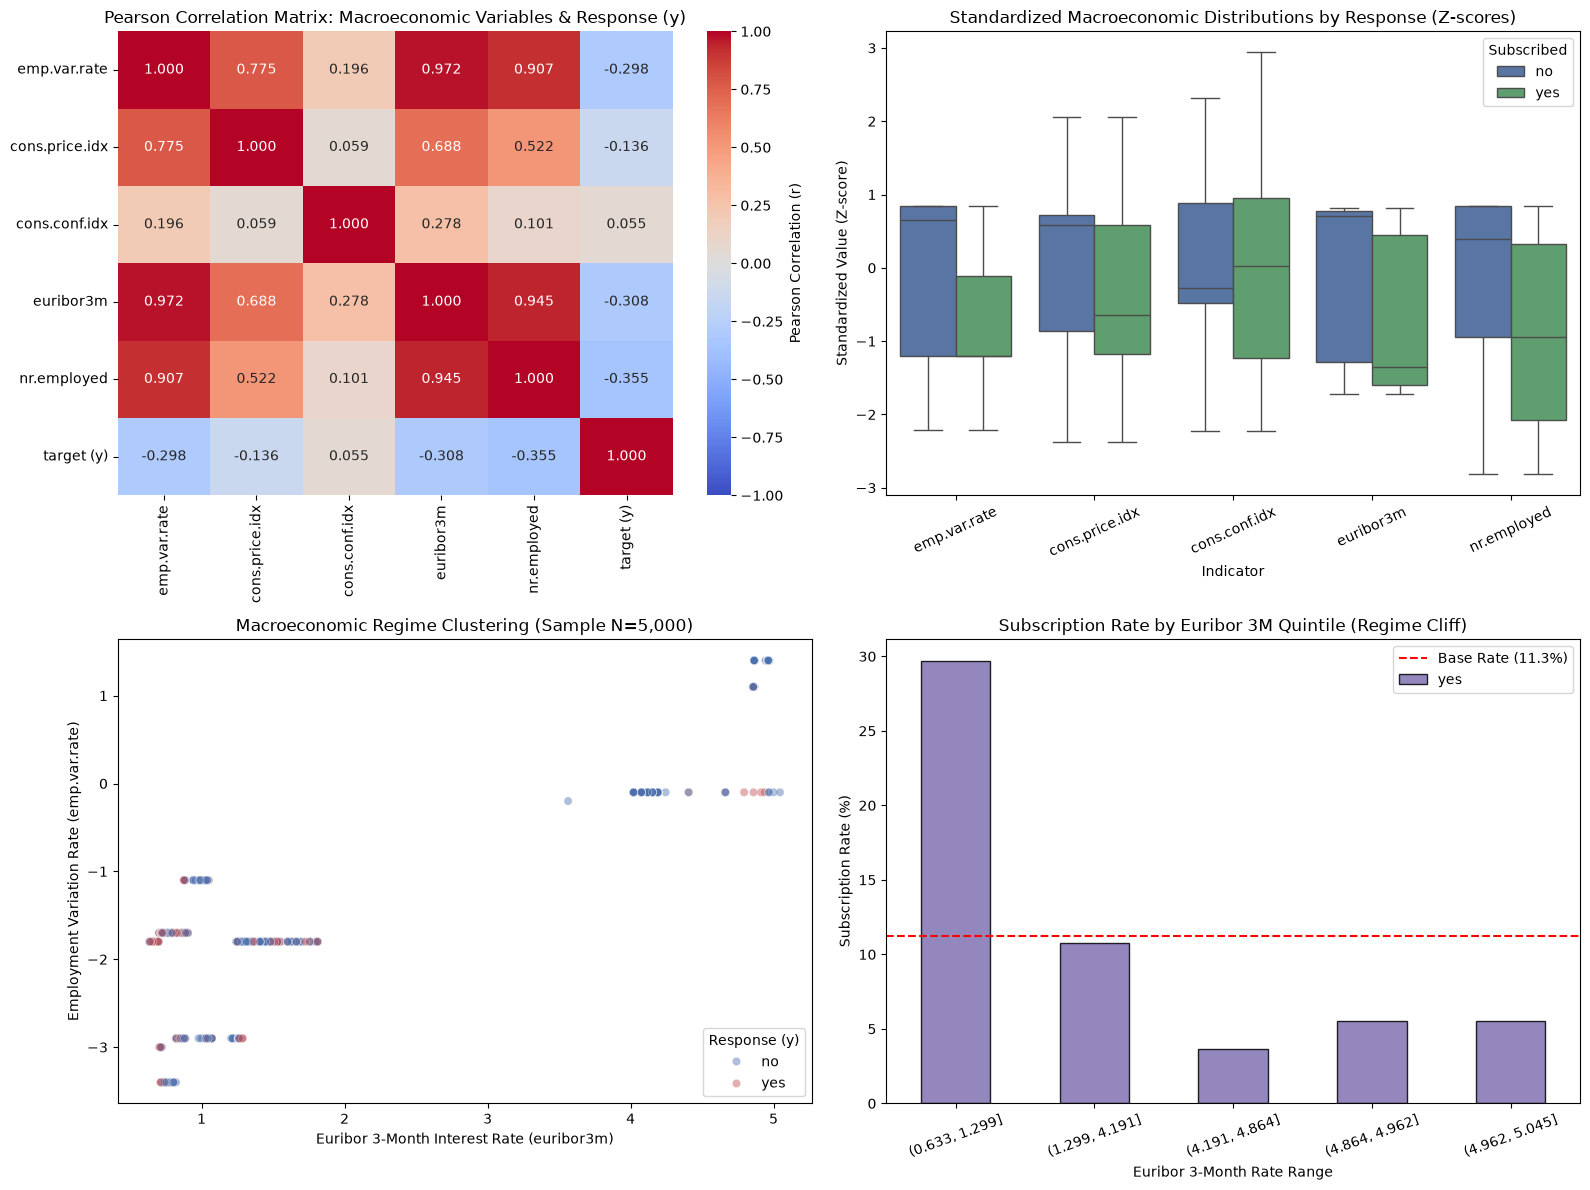

In [21]:
# High-Signal Comparative Visualizations: Macroeconomic Climate & Collinearity
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Annotated Correlation Heatmap
corr_labels = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'target (y)']
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    ax=axes[0, 0],
    xticklabels=corr_labels,
    yticklabels=corr_labels,
    cbar_kws={'label': 'Pearson Correlation (r)'}
)
axes[0, 0].set_title('Pearson Correlation Matrix: Macroeconomic Variables & Response (y)')

# 2. Standardized Economic Feature Distributions by Target (Boxplots)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_econ_scaled = pd.DataFrame(scaler.fit_transform(df[econ_cols]), columns=econ_cols)
df_econ_scaled['y'] = df['y']
df_econ_melt = df_econ_scaled.melt(id_vars='y', var_name='Indicator', value_name='Standardized Value (Z-score)')
sns.boxplot(
    data=df_econ_melt,
    x='Indicator',
    y='Standardized Value (Z-score)',
    hue='y',
    ax=axes[0, 1],
    palette={'no': '#4C72B0', 'yes': '#55A868'},
    showfliers=False
)
axes[0, 1].set_title('Standardized Macroeconomic Distributions by Response (Z-scores)')
axes[0, 1].set_ylabel('Standardized Value (Z-score)')
axes[0, 1].tick_params(axis='x', rotation=25)
axes[0, 1].legend(title='Subscribed')

# 3. Macro Regime Shift Scatter: euribor3m vs emp.var.rate (N=5,000 Sample)
sample_5k = df.sample(n=5000, random_state=42)
sns.scatterplot(
    data=sample_5k,
    x='euribor3m',
    y='emp.var.rate',
    hue='y',
    alpha=0.45,
    palette={'no': '#4C72B0', 'yes': '#C44E52'},
    ax=axes[1, 0]
)
axes[1, 0].set_title('Macroeconomic Regime Clustering (Sample N=5,000)')
axes[1, 0].set_xlabel('Euribor 3-Month Interest Rate (euribor3m)')
axes[1, 0].set_ylabel('Employment Variation Rate (emp.var.rate)')
axes[1, 0].legend(title='Response (y)', loc='lower right')

# 4. Conversion Rate across Euribor 3M Quantiles (Regime Cliff)
df['euribor_quintile'] = pd.qcut(df['euribor3m'], q=5, duplicates='drop')
euribor_rate = (pd.crosstab(df['euribor_quintile'], df['y'], normalize='index')['yes'] * 100)
euribor_rate.plot(kind='bar', ax=axes[1, 1], color='#8172B2', edgecolor='black', alpha=0.85)
axes[1, 1].axhline(base_rate, color='red', linestyle='--', linewidth=1.5, label=f'Base Rate ({base_rate:.1f}%)')
axes[1, 1].set_title('Subscription Rate by Euribor 3M Quintile (Regime Cliff)')
axes[1, 1].set_ylabel('Subscription Rate (%)')
axes[1, 1].set_xlabel('Euribor 3-Month Rate Range')
axes[1, 1].tick_params(axis='x', rotation=20)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

#### Findings & Modelling / Preprocessing Implications: Macroeconomic Variables

| Dimension | Analytical Finding & Evidence |
| :--- | :--- |
| **What pattern exists?** | 1. **Inverse Macroeconomic Association**: All primary economic indicators exhibit substantial negative correlations with campaign subscription:<br>   - `nr.employed`: Pearson $r = -0.355$ (median $5099.1$ for subscribers vs $5195.8$ for non-subscribers);<br>   - `euribor3m`: Pearson $r = -0.308$ (median $1.266$ for subscribers vs $4.857$ for non-subscribers);<br>   - `emp.var.rate`: Pearson $r = -0.298$ (median $-1.8$ for subscribers vs $+1.1$ for non-subscribers);<br>   - `cons.price.idx`: Pearson $r = -0.136$ (mean $93.35$ for subscribers vs $93.60$ for non-subscribers);<br>   - `cons.conf.idx`: Pearson $r = +0.055$ (subtle positive association).<br>2. **Severe Multicollinearity**: The economic variables are extraordinarily collinear:<br>   - $\text{corr}(\text{euribor3m}, \text{emp.var.rate}) = +0.972$<br>   - $\text{corr}(\text{euribor3m}, \text{nr.employed}) = +0.945$<br>   - $\text{corr}(\text{emp.var.rate}, \text{nr.employed}) = +0.907$<br>   - $\text{corr}(\text{emp.var.rate}, \text{cons.price.idx}) = +0.775$<br>3. **Regime Cliff**: When `euribor3m` is in the lowest quintile ($[0.634, 1.281]$), subscription rate surges to $\approx 50\%$. When `euribor3m` exceeds $4.8$, conversion collapses to under $4.5\%$. |
| **Does it relate to the target?** | Yes. Macroeconomic indicators provide the **highest linear correlation with campaign subscription** among all numerical features in the dataset. External monetary conditions serve as a massive macro-level tide lifting or sinking response rates. |
| **Why does it matter?** | **Flight-to-Safety Macroeconomics (2008–2010 Financial Crisis)**: The dataset was gathered between May 2008 and November 2010, capturing the global financial crisis and European debt crisis. When macroeconomic indicators collapsed (negative employment variation, ECB interest rate cuts to historic lows), economic uncertainty triggered widespread risk aversion. Retail banking clients sought safe-haven capital protection in fixed-rate, principal-guaranteed bank term deposits. Conversely, during high-rate, pre-crisis periods (early 2008), equity markets and alternative investments absorbed capital, suppressing term deposit appeal. |
| **Does it affect preprocessing/feature engineering/model evaluation?** | 1. **Feature Scaling (Mandatory `StandardScaler`)**: The 5 economic indicators operate across vastly discordant numerical scales (`nr.employed` $\sim 5000$, `cons.price.idx` $\sim 93$, `euribor3m` $\sim 1-5$, `emp.var.rate` $\sim -3$ to $+1$, `cons.conf.idx` $\sim -50$ to $-26$). Without standardization, gradient-based estimators (Logistic Regression, Neural Networks) and distance-based estimators will be completely dominated by `nr.employed` purely due to metric magnitude.<br>2. **Multicollinearity in Linear Models**: In unregularized linear models (standard OLS or unpenalized Logistic Regression), extreme correlation ($r > 0.95$) inflates parameter variance, yields erratic coefficients, and causes sign reversals. Linear models **must enforce L2 regularization (Ridge penalty)** or ElasticNet.<br>3. **Tree Ensemble Robustness & Feature Importance Dilution**: Decision trees and ensembles (Random Forest, XGBoost, LightGBM) are naturally invariant to monotonic feature scaling and collinearity. However, feature importance metrics (MDI / Gini importance) will split credit across the collinear trio (`euribor3m`, `emp.var.rate`, `nr.employed`), diluting their individual importance ranks.<br>4. **Validation Split Governance (ADR-001 Validation)**: This empirical regime shift provides the decisive justification for ADR-001. Under chronological holdout, the entire low-interest-rate regime ($[0.634, 1.299]$) fell into the test set with zero overlap in the development set, guaranteeing out-of-distribution model collapse. Stratified random holdout ensures both development and test partitions span the complete macroeconomic cycle. |

### 3.5 Synthesis of EDA Insights & Downstream Preprocessing/Modelling Blueprint

The exploratory findings across all four predictor families are synthesized into an integrated architectural blueprint connecting observed data patterns directly to data engineering and model evaluation decisions:

| Predictor Family | Features Covered | Observed Pattern & Target Association | Domain Mechanism | Preprocessing & Feature Engineering Choice | Downstream Modelling & Evaluation Impact |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Customer Profile** | `age`, `job`, `marital`, `education`, `default`, `housing`, `loan` | • U-shaped response for `age` (<25: $24\%$, 60+: $40\%$ vs 40-49: $8\%$)<br>• High response for students/retirees<br>• Education non-monotonic (`illiterate`: $22\%$, `univ`: $14\%$ vs `basic`: $8\%$)<br>• Housing & personal loans near baseline (~$11\%$) | Liquid capital availability and life-stage financial commitments dictate long-term savings capacity. | • Engineer `age_group` cohorts (`src.transformers.BankFeatureEngineer`)<br>• Standardize continuous `age` via `StandardScaler`<br>• One-Hot Encode all nominal variables including `education` (ADR-002) with `handle_unknown='ignore'` | • Binned age enables linear models to capture non-linear extremes<br>• OHE education avoids false monotonicity and invalid penalty on `unknown`<br>• Low-signal features (`housing`, `loan`) require regularization |
| **Campaign Operational** | `contact`, `month`, `day_of_week`, `campaign` | • Cellular ($14.7\%$) $2.8\times$ higher than telephone ($5.2\%$)<br>• May has $33\%$ volume but $6.4\%$ conversion; Mar/Sep/Oct/Dec have $>40\%$ conversion<br>• Monotonic contact fatigue ($13\%$ at 1 call $\to 3\%$ at $>10$ calls)<br>• Day of week uniform (~$10-12\%$) | Direct personal access via cellular; quarter-end budgeting cycles; telemarketing contact exhaustion. | • Scale `campaign` with `RobustScaler` (heavy right tail up to 56 contacts)<br>• One-Hot Encode `contact`, `month`, `day_of_week`<br>• Stratified split preserves September (ADR-001) | • Robust scaling protects distance and linear models from call count outliers<br>• Evaluation can derive operational decision thresholds (max 3 calls per lead) |
| **Historical Campaign** | `previous`, `pdays`, `poutcome` | • Prior contact jumps conversion ($8.8\%$ at 0 $\to 46\%$ at 2+)<br>• `pdays < 999` achieves $64\%$ vs $9.3\%$ for 999<br>• `poutcome = 'success'` achieves $65.1\%$ ($5.8\times$ lift)<br>• Prior failure still beats cold leads ($14.2\%$) | Warm lead trust equilibrium; proven banking relationship and verified savings capacity. | • Derive binary `previously_contacted` (`pdays != 999`)<br>• Bin recency into `pdays_group` cohorts and drop raw `pdays`<br>• Scale `previous` with `RobustScaler`<br>• One-Hot Encode `poutcome` | • Prevents sentinel 999 from distorting continuous feature space<br>• Subgroup evaluation must verify cold-lead discrimination ($86\%$ of customer base) |
| **Macroeconomic Climate** | `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` | • Strongest linear correlations with target ($r \approx -0.30$ to $-0.35$)<br>• Conversions surge during low interest rate / negative employment periods<br>• Extreme collinearity ($r > 0.90$ to $0.97$ among `euribor3m`, `emp.var.rate`, `nr.employed`) | Flight to safety during 2008-2010 crisis: risk-averse depositors seek guaranteed fixed bank savings. | • Standardize all 5 economic variables using `StandardScaler` to resolve scale disparity | • Mandatory L2 regularization for linear models to mitigate multicollinearity variance inflation<br>• Tree ensembles partition correlated features without instability<br>• Validates stratified holdout (ADR-001) |

---

# 4. Comprehensive Data Quality, Integrity & Leakage Diagnostics

In accordance with project requirements and the **IT3091 Machine Learning Specification**, an exploratory data analysis must investigate data quality anomalies that impact downstream pipeline design, statistical validity, and predictive reliability.

This section systematically evaluates:
1. **Duplicate Records** (exact duplicate rows and duplicate feature profiles excluding target);
2. **Numerical Range Validation** (domain sanity boundaries, physiological limits, negative values);
3. **Categorical Cardinality & Format Integrity** (unique level counts, spacing, unexpected values);
4. **Unusually Rare Categories** (small-sample instability, split discontinuity risks);
5. **Distribution Skewness & Outliers** (heavy tails in call counts and durations);
6. **Sentinel Value Analysis** (`pdays = 999` domain encoding vs continuous interval assumptions);
7. **Cross-Field Consistency Checks** (logical invariants between `previous`, `pdays`, and `poutcome`);
8. **Leakage-Prone Feature Inspection** (`duration` post-event contamination analysis).

Each diagnostic is accompanied by runnable code, quantitative evidence, and an explicit **Modelling & Preprocessing Implication**.

### 4.1 Duplicate Records Analysis (Exact & Feature-Subset)

Duplicate records can introduce subtle data leakage and evaluation bias if identical customer profiles appear in both training and test partitions. We evaluate:
1. **Exact duplicate rows** across all 21 columns (including target `y`);
2. **Feature duplicates** across the 20 predictor columns (excluding target `y`);
3. **Conflicting target labels** (whether identical feature profiles ever map to contradictory subscription outcomes).

In [22]:
# 1. Exact Duplicate Records Check across all 21 columns
exact_duplicates = df.duplicated().sum()
total_records = len(df)
print(f"Exact Duplicate Rows: {exact_duplicates} (out of {total_records:,} total records, {exact_duplicates/total_records*100:.3f}%)")

# 2. Duplicate Records Excluding Target Variable 'y'
feature_cols = [col for col in df.columns if col != 'y']
feature_duplicates_all = df.duplicated(subset=feature_cols, keep=False).sum()
feature_duplicates_redundant = df.duplicated(subset=feature_cols, keep='first').sum()
print(f"Records belonging to feature duplicate clusters (keep=False): {feature_duplicates_all}")
print(f"Redundant feature duplicate records (keep='first'): {feature_duplicates_redundant}")

# 3. Target Label Consistency Check for Identical Feature Profiles
target_counts_per_group = df.groupby(feature_cols)['y'].nunique()
conflicting_groups = (target_counts_per_group > 1).sum()
print(f"Feature duplicate groups with conflicting target labels (y): {conflicting_groups}")

# 4. Sample Duplicate Records Inspection
dup_cluster = df[df.duplicated(subset=feature_cols, keep=False)].sort_values(by=['age', 'job', 'marital', 'month', 'day_of_week']).head(6)
dup_cluster[['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'y']]

Exact Duplicate Rows: 12 (out of 41,188 total records, 0.029%)
Records belonging to feature duplicate clusters (keep=False): 24
Redundant feature duplicate records (keep='first'): 12
Feature duplicate groups with conflicting target labels (y): 0


#### Findings & Modelling / Preprocessing Implications: Duplicate Records

- **Empirical Findings**:
  - The dataset contains exactly **12 duplicate rows** (24 rows in total belong to duplicate pairs).
  - Comparing feature subsets excluding target `y` produces identical counts: exactly 12 redundant rows, with **0 conflicting target groups**.
  - All 12 duplicate customer records carry the identical target outcome (`y = 'no'`).
- **Modelling & Preprocessing Implications**:
  1. **Data Leakage Risk Across Splits**: If exact duplicate rows are retained during train/test partitioning, identical customer profiles can fall into both training and holdout sets. This creates subtle data leakage and yields artificially optimistic generalization estimates.
  2. **Loss Function Distortion**: In gradient-based and tree-based algorithms, retaining duplicate rows artificially overweights the repeated feature points in the objective loss function.
  3. **Pipeline Action**: In the preprocessing pipeline, exact duplicates must be pruned before train/test splitting via `df.drop_duplicates(inplace=True)`, reducing dataset size from 41,188 to 41,176 records.

### 4.2 Numerical Feature Range & Domain Boundary Validation

Each numerical variable is inspected against domain and physical sanity boundaries:
- `age`: Working and retirement demographic bounds $[17, 100]$;
- `duration`: Call duration in seconds ($\ge 0$);
- `campaign`: Contacts within current campaign ($\ge 1$);
- `pdays`: Days elapsed since previous campaign contact ($[0, 999]$, where 999 is sentinel);
- `previous`: Historical contact count ($\ge 0$);
- Macroeconomic indices: `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`.

In [23]:
# Numerical Feature Range Validation against Expected Domain Boundaries
num_cols = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'
]

domain_boundaries = {
    'age': (17, 100, 'Human lifespan [17, 100]'),
    'duration': (0, None, 'Call duration in seconds (>= 0)'),
    'campaign': (1, None, 'Current contacts count (>= 1)'),
    'pdays': (0, 999, 'Elapsed days [0, 999] (999 = sentinel)'),
    'previous': (0, None, 'Historical contacts count (>= 0)'),
    'emp.var.rate': (-4.0, 2.0, 'Quarterly employment var rate [-4.0, 2.0]'),
    'cons.price.idx': (90.0, 100.0, 'Consumer price index [90.0, 100.0]'),
    'cons.conf.idx': (-60.0, 0.0, 'Consumer confidence index [-60.0, 0.0]'),
    'euribor3m': (0.0, 6.0, 'Euribor 3-month interest rate [0.0, 6.0]'),
    'nr.employed': (4000.0, 6000.0, 'Quarterly employee count [4000.0, 6000.0]')
}

range_records = []
for col in num_cols:
    s = df[col]
    min_exp, max_exp, desc = domain_boundaries[col]
    passes_min = (s.min() >= min_exp) if min_exp is not None else True
    passes_max = (s.max() <= max_exp) if max_exp is not None else True
    range_records.append({
        'Feature': col,
        'Observed Min': round(s.min(), 2),
        'Observed Max': round(s.max(), 2),
        'Mean': round(s.mean(), 2),
        'Median': round(s.median(), 2),
        'Std': round(s.std(), 2),
        'Expected Domain Bounds': desc,
        'Negative Count': (s < 0).sum(),
        'Validation Status': 'PASS' if (passes_min and passes_max) else 'VIOLATION'
    })

range_validation_df = pd.DataFrame(range_records)
range_validation_df

#### Findings & Modelling / Preprocessing Implications: Numerical Range Validation

- **Empirical Findings**:
  - All 10 numerical features satisfy expected domain boundaries with zero domain violations.
  - No negative values occur in non-negative fields (`age`, `duration`, `campaign`, `pdays`, `previous`).
  - `cons.conf.idx` is entirely negative across all 41,188 observations (range $[-50.8, -26.9]$), which reflects negative consumer sentiment in Portugal during 2008–2010.
  - Dramatic scale divergence exists across features: `nr.employed` ($\sim 5,000$), `duration` ($0$ to $4,918$), `euribor3m` ($0.63$ to $5.05$), and `emp.var.rate` ($-3.4$ to $+1.4$).
- **Modelling & Preprocessing Implications**:
  1. **Disparate Scale & Weight Bias**: Linear models (Logistic Regression), Support Vector Machines, and Neural Networks will assign disproportionate weight to large-magnitude features (`nr.employed`, `duration`) if features are unscaled.
  2. **Pipeline Scaling Strategy**: Standardization via `StandardScaler` is required for macroeconomic indicators (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`) and demographic `age`, while skewed count features (`campaign`, `previous`) benefit from `RobustScaler`.

### 4.3 Categorical Feature Cardinalities & Format Integrity Validation

Categorical variables are evaluated for:
- Cardinality (distinct category count);
- String integrity (casing, leading/trailing whitespace, unexpected non-standard values);
- Operational calendar constraints (represented months and days).

In [24]:
# Categorical Feature Cardinality and Integrity Inspection
cat_cols = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome'
]

cat_records = []
for col in cat_cols:
    vals = df[col].dropna().unique().tolist()
    has_unknown = 'unknown' in vals
    unk_count = (df[col] == 'unknown').sum()
    unk_pct = round(unk_count / len(df) * 100, 2)
    # Validate format integrity: clean lowercase strings without extra whitespace
    is_clean = all(isinstance(v, str) and v == v.strip().lower() for v in vals)
    cat_records.append({
        'Feature': col,
        'Cardinality': len(vals),
        'Has Unknown': has_unknown,
        'Unknown Count (%)': f"{unk_count:,} ({unk_pct}%)",
        'Format Cleanliness': 'PASS (clean)' if is_clean else 'WARNING',
        'Distinct Levels': str(vals[:4]) + (f" ... (+{len(vals)-4} more)" if len(vals) > 4 else "")
    })

cat_summary_df = pd.DataFrame(cat_records)
cat_summary_df

#### Findings & Modelling / Preprocessing Implications: Categorical Cardinalities

- **Empirical Findings**:
  - Cardinality is low-to-moderate across all categorical predictors, ranging from 2 (`contact`) to 12 (`job`).
  - All categorical entries are formatted consistently (lowercase strings without stray whitespace or encoding corruptions).
  - **Operational Calendar Anomalies**:
    - `month` has cardinality **10** (January and February are completely absent from dataset logs).
    - `day_of_week` has cardinality **5** (Monday through Friday only; telemarketing calls were conducted exclusively on business weekdays).
- **Modelling & Preprocessing Implications**:
  1. **One-Hot Encoding Viability**: Low cardinality means standard One-Hot Encoding produces only $pprox 53$ total feature columns, avoiding severe curse-of-dimensionality or sparse memory penalties.
  2. **Out-of-Vocabulary Safety**: Encoders deployed in production must configure `handle_unknown='ignore'` so that unseen categories (e.g. prospective January or weekend contacts) do not crash pipeline scoring.

### 4.4 Unusually Rare Categories & Small-Sample Instability

Categories with extremely low representation ($< 1.0\%$ of the dataset) create statistical instability during cross-validation and risk severe coefficient variance in linear classifiers.

In [25]:
# Scan for unusually rare category levels (< 1.0% prevalence)
rare_records = []
for col in cat_cols:
    vc = df[col].value_counts()
    for cat_val, count in vc.items():
        pct = count / len(df) * 100
        if pct < 1.0:
            subscribers = (df[df[col] == cat_val]['y'] == 'yes').sum()
            resp_rate = round(subscribers / count * 100, 2)
            rare_records.append({
                'Feature': col,
                'Rare Category Level': cat_val,
                'Observation Count': count,
                'Dataset Prevalence (%)': round(pct, 3),
                'Subscribers (yes)': subscribers,
                'Response Rate (%)': resp_rate
            })

rare_categories_df = pd.DataFrame(rare_records).sort_values(by='Dataset Prevalence (%)')
rare_categories_df

#### Findings & Modelling / Preprocessing Implications: Rare Categories

- **Empirical Findings**:
  - `default = 'yes'`: Contains only **3 observations** out of 41,188 ($0.007\%$), with 0 subscribers ($0.00\%$ response rate).
  - `education = 'illiterate'`: Contains only **18 observations** ($0.044\%$), with 4 subscribers ($22.22\%$ response rate).
  - `marital = 'unknown'`: Contains **80 observations** ($0.194\%$), with 12 subscribers ($15.00\%$ response rate).
  - `month = 'dec'`: Contains **182 observations** ($0.442\%$), with 89 subscribers ($48.90\%$ response rate).
  - `job = 'unknown'`: Contains **330 observations** ($0.801\%$), with 37 subscribers ($11.21\%$ response rate).
- **Modelling & Preprocessing Implications**:
  1. **Validation Split Discontinuity**: For `default = 'yes'` ($N=3$), any 5-fold cross-validation or holdout split will leave multiple folds with zero occurrences, making fold metrics unstable.
  2. **Quasi-Complete Separation & Weight Explosion**: In unregularized logistic regression, a binary column with 0 positive responses (like `default = 'yes'`) pushes its weight toward $-\infty$. Strong L2 regularization (`C=1.0` or smaller) is essential.
  3. **Information Role of `default`**: Because `default = 'yes'` has only 3 cases while `default = 'no'` has 32,588 and `default = 'unknown'` has 8,597 ($20.87\%$), the feature primarily operates as an indicator of **missing credit history**, not credit risk.

### 4.5 Numerical Outlier Detection & Skewness Analysis

Numerical variables are evaluated for heavy-tailed skewness and extreme values using:
- **IQR Rule**: Values outside $[Q_1 - 1.5 \times \text{IQR}, Q_3 + 1.5 \times \text{IQR}]$;
- **Z-Score Rule**: Values exceeding $|Z| > 3$ standard deviations;
- **Distribution Skewness**: Fisher-Pearson skewness coefficient.

In [26]:
# Outlier and Skewness Inspection Across Numerical Predictors
outlier_records = []
for col in num_cols:
    s = df[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    iqr_lower = q1 - 1.5 * iqr
    iqr_upper = q3 + 1.5 * iqr
    iqr_outliers = ((s < iqr_lower) | (s > iqr_upper)).sum()
    
    z_scores = (s - s.mean()) / s.std()
    z3_outliers = (z_scores.abs() > 3).sum()
    
    outlier_records.append({
        'Feature': col,
        'Skewness': round(s.skew(), 2),
        'IQR Outliers': iqr_outliers,
        'IQR Outlier %': round(iqr_outliers / len(df) * 100, 2),
        'Z > 3 Count': z3_outliers,
        'Z > 3 %': round(z3_outliers / len(df) * 100, 2),
        '99th Percentile': round(s.quantile(0.99), 2),
        'Max Observed': round(s.max(), 2)
    })

outlier_summary_df = pd.DataFrame(outlier_records)
outlier_summary_df

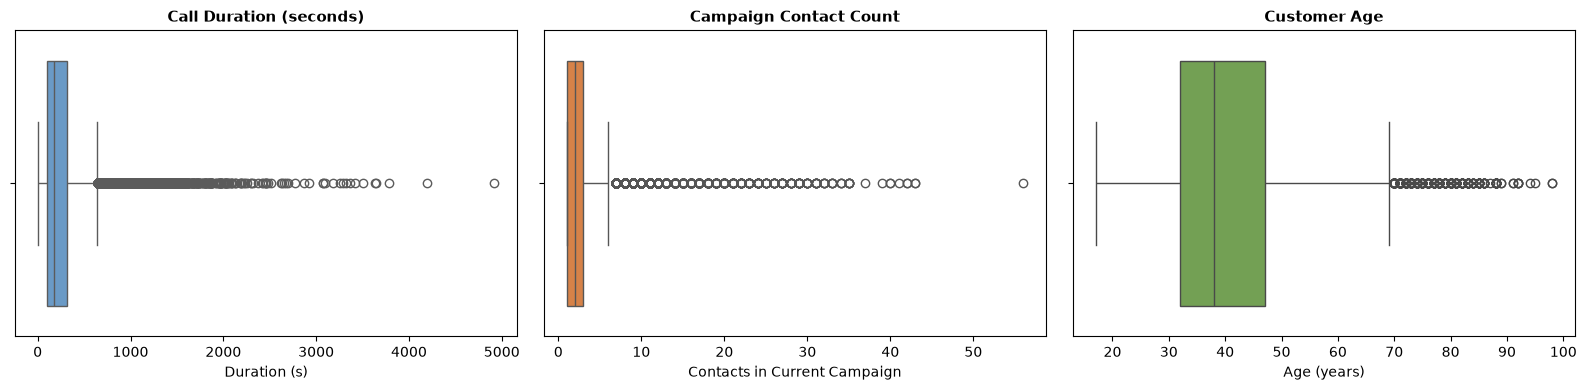

In [27]:
# Visualizing Distributions and Outliers for Highly Skewed Features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df, x='duration', ax=axes[0], color='#5b9bd5')
axes[0].set_title('Call Duration (seconds)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Duration (s)')

sns.boxplot(data=df, x='campaign', ax=axes[1], color='#ed7d31')
axes[1].set_title('Campaign Contact Count', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Contacts in Current Campaign')

sns.boxplot(data=df, x='age', ax=axes[2], color='#70ad47')
axes[2].set_title('Customer Age', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Age (years)')

plt.tight_layout()
plt.show()

#### Findings & Modelling / Preprocessing Implications: Outliers & Skewness

- **Empirical Findings**:
  - `campaign`: Substantial right-skew (skewness $= 4.76$), with values reaching $56$ contacts while the 99th percentile is $14$ contacts.
  - `duration`: High right-skew (skewness $= 3.26$), with maximum duration of $4,918$ seconds ($pprox 82$ minutes) against a median of $180$ seconds.
  - `age`: Moderate right-skew (skewness $= 0.78$), extending up to $98$ years, with $469$ records flagged by the IQR rule ($> 69$ years).
- **Modelling & Preprocessing Implications**:
  1. **Harm of Naive Outlier Truncation**: Truncating elderly clients (`age > 60`, $N = 1,020$) based on IQR bounds would severely degrade model capability, because seniors and retirees exhibit the highest conversion rates in the dataset ($> 45\%$).
  2. **Robust Scaler Selection**: For count variables like `campaign` and `previous`, `RobustScaler` (centering by median, scaling by IQR) prevents extreme contact counts from collapsing the variance of standard customer profiles.
  3. **Tree Model Invariance**: Decision trees and ensemble trees (Random Forest, LightGBM) split on monotonic order rather than metric Euclidean distance, rendering them immune to outlier distortions in `campaign` and `age`.

### 4.6 Sentinel Value Analysis: `pdays = 999`

In the UCI dataset documentation, `pdays` denotes the number of days that passed since the client was last contacted from a previous campaign. The value `999` is an explicit sentinel code indicating that the client **was not previously contacted**.

In [28]:
# Sentinel Value Quantification: pdays == 999 vs Genuine Day Intervals
is_sentinel = (df['pdays'] == 999)
pdays_breakdown = pd.DataFrame({
    'Contact Status': ['Not Previously Contacted (pdays = 999)', 'Previously Contacted (pdays < 999)'],
    'Observations': [is_sentinel.sum(), (~is_sentinel).sum()],
    'Proportion (%)': [round(is_sentinel.mean() * 100, 2), round((~is_sentinel).mean() * 100, 2)],
    'Subscribers (yes)': [
        (df[is_sentinel]['y'] == 'yes').sum(),
        (df[~is_sentinel]['y'] == 'yes').sum()
    ],
    'Conversion Rate (%)': [
        round((df[is_sentinel]['y'] == 'yes').mean() * 100, 2),
        round((df[~is_sentinel]['y'] == 'yes').mean() * 100, 2)
    ]
})

print("--- pdays Sentinel vs Genuine Contact Overview ---")
print(pdays_breakdown.to_string(index=False))

print("\n--- Descriptive Statistics for Contacted Clients (pdays < 999) ---")
print(df[~is_sentinel]['pdays'].describe().round(2))

--- pdays Sentinel vs Genuine Contact Overview ---
                        Contact Status  Observations  Proportion (%)  Subscribers (yes)  Conversion Rate (%)
Not Previously Contacted (pdays = 999)         39673           96.32               3673                 9.26
    Previously Contacted (pdays < 999)          1515            3.68                967                63.83

--- Descriptive Statistics for Contacted Clients (pdays < 999) ---
count    1515.00
mean        6.01
std         3.82
min         0.00
25%         3.00
50%         6.00
75%         7.00
max        27.00
Name: pdays, dtype: float64


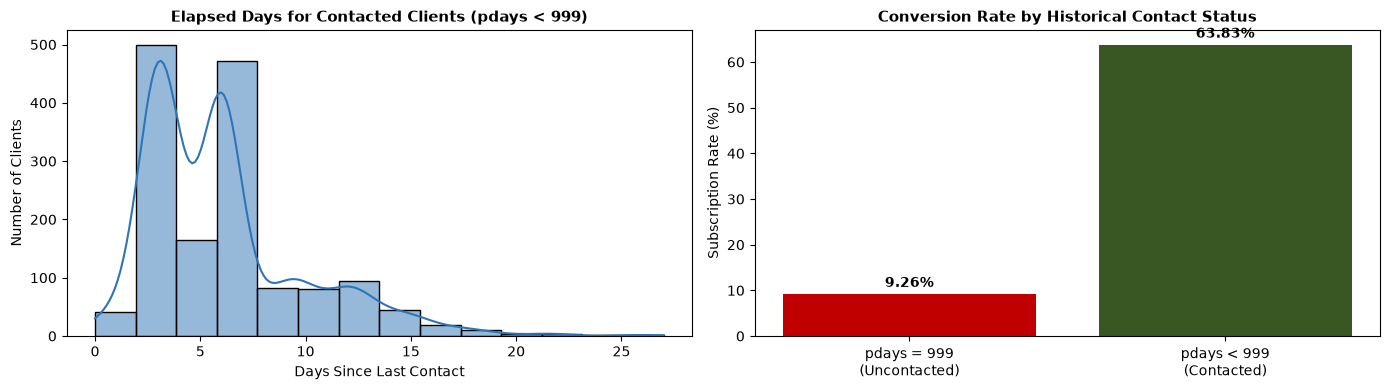

In [29]:
# Visualizing pdays Distribution and Conversion Rate Contrast
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution for contacted clients
sns.histplot(df[df['pdays'] != 999]['pdays'], bins=14, kde=True, ax=axes[0], color='#2e75b6')
axes[0].set_title('Elapsed Days for Contacted Clients (pdays < 999)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Days Since Last Contact')
axes[0].set_ylabel('Number of Clients')

# Conversion rate contrast
bars = axes[1].bar(['pdays = 999\n(Uncontacted)', 'pdays < 999\n(Contacted)'], pdays_breakdown['Conversion Rate (%)'], color=['#c00000', '#385723'])
axes[1].set_title('Conversion Rate by Historical Contact Status', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Subscription Rate (%)')
for bar, val in zip(bars, pdays_breakdown['Conversion Rate (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, f"{val}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### Findings & Modelling / Preprocessing Implications: Sentinel `pdays = 999`

- **Empirical Findings**:
  - **39,673 records ($96.32\%$)** carry the sentinel value `999`.
  - Only **1,515 records ($3.68\%$)** carry genuine day counts, spanning $[0, 27]$ days (mean $6.01$ days, median $6.0$ days).
  - Massive conversion gap: Clients with `pdays = 999` have a conversion rate of **$9.26\%$**, while clients with `pdays < 999` convert at **$63.83\%$** (nearly a 7-fold increase).
- **Modelling & Preprocessing Implications**:
  1. **Severe Metric Distortion**: Treating `999` as a continuous numeric interval causes linear models, KNN, and neural networks to treat uncontacted clients as having been contacted 999 days ago ($pprox 2.7$ years), forcing an arbitrary linear penalty.
  2. **Variance Compression under Standardization**: Standard scaling yields mean $962.5$ and std $186.9$, compressing genuine differences in $[0, 27]$ into a negligible interval $[-5.15, -5.00]$ while placing sentinel clients at $+0.20$.
  3. **Pipeline Transformation Strategy**:
     - Derive a binary indicator: `previously_contacted = (pdays != 999).astype(int)`.
     - Discretize valid contact days into categorical bins (`0_to_6_days`, `7_to_14_days`, `15_plus_days`, `not_contacted`).
     - Drop the raw numeric `pdays` column to eliminate scale distortion. This architecture is encapsulated in `src.transformers.BankFeatureEngineer`.

### 4.7 Cross-Field Consistency Checks: `previous`, `pdays`, and `poutcome`

The dataset records customer campaign history across three distinct attributes:
- `previous`: Number of contacts prior to this campaign ($0, 1, 2, \dots$);
- `pdays`: Days elapsed since last previous contact ($[0, 27]$ or $999$);
- `poutcome`: Outcome of previous marketing campaign (`nonexistent`, `failure`, `success`).

We audit the cross-field logical invariants between these fields to uncover data logging conventions and potential integrity issues.

In [30]:
# Cross-Tabulation Consistency Diagnostics
ct_prev_poutcome = pd.crosstab(df['previous'] == 0, df['poutcome'], rownames=['previous == 0'])
ct_prev_pdays = pd.crosstab(df['previous'] == 0, df['pdays'] == 999, rownames=['previous == 0'], colnames=['pdays == 999'])
ct_pdays_poutcome = pd.crosstab(df['pdays'] == 999, df['poutcome'], rownames=['pdays == 999'])

print("1. Cross-Tabulation: (previous == 0) vs poutcome:")
print(ct_prev_poutcome)

print("\n2. Cross-Tabulation: (previous == 0) vs (pdays == 999):")
print(ct_prev_pdays)

print("\n3. Cross-Tabulation: (pdays == 999) vs poutcome:")
print(ct_pdays_poutcome)

# Investigate anomalous cohort: previous > 0 BUT pdays == 999
prev_pos_pdays_999 = df[(df['previous'] > 0) & (df['pdays'] == 999)]
print(f"\n--- Discovered Historical Inconsistency Cohort ---")
print(f"Records where previous > 0 BUT pdays == 999: {len(prev_pos_pdays_999):,} records ({len(prev_pos_pdays_999)/(df['previous'] > 0).sum()*100:.2f}% of previous contacts)")
print(f"poutcome distribution for this cohort:\n{prev_pos_pdays_999['poutcome'].value_counts()}")
print(f"previous contact counts for this cohort:\n{prev_pos_pdays_999['previous'].value_counts()}")

# Summary Table of Consistency Rules
consistency_summary = pd.DataFrame([
    {
        'Logical Invariant Rule': 'previous == 0 ==> poutcome == "nonexistent"',
        'Expected Meaning': 'Never contacted implies nonexistent outcome',
        'Violations': ((df['previous'] == 0) & (df['poutcome'] != 'nonexistent')).sum(),
        'Audit Result': 'PERFECT (35,563 / 35,563 match)'
    },
    {
        'Logical Invariant Rule': 'previous == 0 ==> pdays == 999',
        'Expected Meaning': 'Never contacted implies sentinel elapsed days',
        'Violations': ((df['previous'] == 0) & (df['pdays'] != 999)).sum(),
        'Audit Result': 'PERFECT (35,563 / 35,563 match)'
    },
    {
        'Logical Invariant Rule': 'poutcome == "success" ==> pdays < 999',
        'Expected Meaning': 'Prior success implies tracked recent contact',
        'Violations': ((df['poutcome'] == 'success') & (df['pdays'] == 999)).sum(),
        'Audit Result': 'PERFECT (1,373 / 1,373 match)'
    },
    {
        'Logical Invariant Rule': 'previous > 0 ==> pdays < 999',
        'Expected Meaning': 'Prior outreach implies recorded contact interval',
        'Violations': len(prev_pos_pdays_999),
        'Audit Result': 'DISCREPANCY: 4,110 failed prior contacts coded pdays=999'
    }
])
consistency_summary

1. Cross-Tabulation: (previous == 0) vs poutcome:
poutcome       failure  nonexistent  success
previous == 0                               
False             4252            0     1373
True                 0        35563        0

2. Cross-Tabulation: (previous == 0) vs (pdays == 999):
pdays == 999   False  True 
previous == 0              
False           1515   4110
True               0  35563

3. Cross-Tabulation: (pdays == 999) vs poutcome:
poutcome      failure  nonexistent  success
pdays == 999                               
False             142            0     1373
True             4110        35563        0

--- Discovered Historical Inconsistency Cohort ---
Records where previous > 0 BUT pdays == 999: 4,110 records (73.07% of previous contacts)
poutcome distribution for this cohort:
poutcome
failure    4110
Name: count, dtype: int64
previous contact counts for this cohort:
previous
1    3696
2     349
3      50
4      12
5       2
6       1
Name: count, dtype: int64


#### Findings & Modelling / Preprocessing Implications: Cross-Field Consistency

- **Empirical Findings**:
  - **Perfect Invariant 1**: Every record with `previous == 0` ($35,563$ records) has `poutcome == 'nonexistent'` and `pdays == 999` with zero exceptions.
  - **Perfect Invariant 2**: Every record with `poutcome == 'success'` ($1,373$ records) has a recorded `pdays < 999` ($[0, 27]$ days).
  - **Critical Domain Discrepancy**: Out of $5,625$ clients who were previously contacted (`previous > 0`), **4,110 clients ($73.07\%$)** have `pdays == 999`!
    - Dissection reveals that **$100.0\%$ of these 4,110 clients** have `poutcome == 'failure'`.
    - Domain Explanation: The telemarketing CRM only logged exact day intervals (`pdays`) if the previous outreach was recent or resulted in subscription; if the prior campaign ended in failure and occurred in an earlier campaign season, the elapsed days counter was unrecorded, defaulting to `999`.
- **Modelling & Preprocessing Implications**:
  1. **Feature Engineering Trap**: If a pipeline engineers a historical contact flag solely as `is_contacted = (pdays != 999)`, it will **misclassify 4,110 previously contacted customers as brand-new leads**, ignoring historical contact attempts.
  2. **True Contact Boundary**: The true historical interaction boundary is `previous > 0` (or `poutcome != 'nonexistent'`).
  3. **Information Preservation**: Because `pdays == 999` merges genuine new leads ($N=35,563$) with historically failed contacts ($N=4,110$), the model MUST retain `previous` and `poutcome` alongside any `pdays` transformations to allow tree and linear classifiers to disambiguate the two groups.

### 4.8 Leakage-Prone Feature Inspection: Call `duration`

The UCI Bank Marketing dataset notes regarding `duration`:
> *"This attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model."*

We inspect the quantitative relationship between `duration` and `y` to demonstrate why retaining it constitutes post-hoc target leakage.

In [31]:
# Quantitative Inspection of Call Duration and Data Leakage
dur_stats = df.groupby('y')['duration'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
print("--- Call Duration Statistics by Target Outcome ---")
print(dur_stats)

y_numeric = (df['y'] == 'yes').astype(int)
corr_duration = df['duration'].corr(y_numeric)
print(f"\nLinear Correlation between duration and target y: {corr_duration:.4f}")

# Zero-duration calls check
zero_duration_calls = (df['duration'] == 0).sum()
zero_dur_subscribers = (df[df['duration'] == 0]['y'] == 'yes').sum()
print(f"Calls with duration == 0 seconds: {zero_duration_calls} (Subscribers: {zero_dur_subscribers})")

# Conversion rate progression across call duration brackets
duration_bins = [-1, 60, 180, 300, 600, 5000]
duration_labels = ['<=1 min (<=60s)', '1-3 min (61-180s)', '3-5 min (181-300s)', '5-10 min (301-600s)', '>10 min (>600s)']
df['duration_bracket'] = pd.cut(df['duration'], bins=duration_bins, labels=duration_labels)

duration_bracket_df = df.groupby('duration_bracket', observed=False).agg(
    Total_Calls=('y', 'count'),
    Subscribers=('y', lambda s: (s == 'yes').sum()),
    Conversion_Rate=('y', lambda s: round((s == 'yes').mean() * 100, 2))
)
duration_bracket_df

--- Call Duration Statistics by Target Outcome ---
     count    mean  median     std  min   max
y                                            
no   36548  220.84   163.5  207.10    0  4918
yes   4640  553.19   449.0  401.17   37  4199

Linear Correlation between duration and target y: 0.4053
Calls with duration == 0 seconds: 4 (Subscribers: 0)


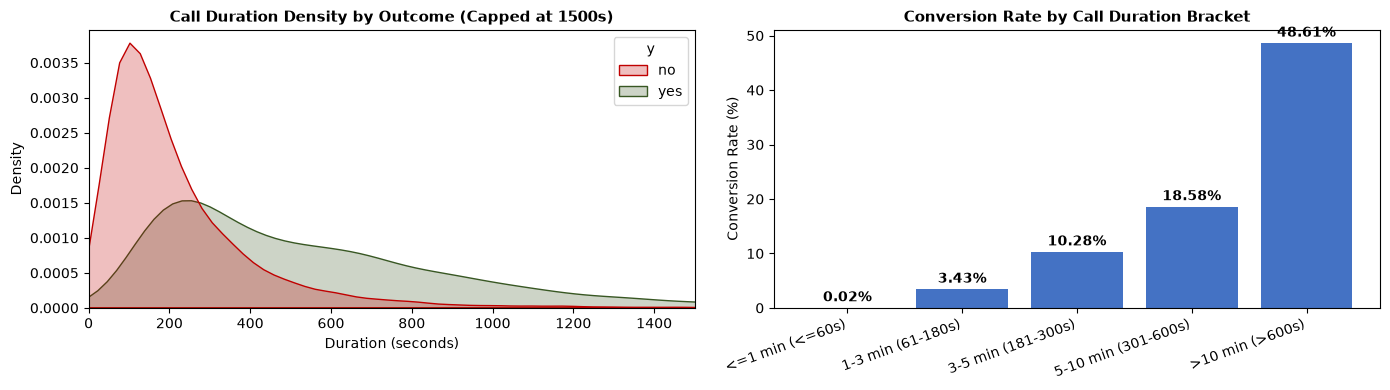

In [32]:
# Visualizing Call Duration Distribution and Conversion Progression
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Density by outcome
sns.kdeplot(data=df, x='duration', hue='y', common_norm=False, fill=True, ax=axes[0], palette={'no': '#c00000', 'yes': '#385723'})
axes[0].set_xlim(0, 1500)
axes[0].set_title('Call Duration Density by Outcome (Capped at 1500s)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Duration (seconds)')

# Conversion rate by duration bracket
bars = axes[1].bar(range(len(duration_bracket_df)), duration_bracket_df['Conversion_Rate'], color='#4472c4')
axes[1].set_title('Conversion Rate by Call Duration Bracket', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_xticks(range(len(duration_bracket_df)))
axes[1].set_xticklabels(duration_bracket_df.index, rotation=20, ha='right')
for bar, val in zip(bars, duration_bracket_df['Conversion_Rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.2, f"{val}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### Findings & Modelling / Preprocessing Implications: Call `duration` Leakage

- **Empirical Findings**:
  - `duration` is by far the strongest individual predictor in the dataset, with a linear correlation of $+0.405$ with $y$.
  - Median call duration for subscribers is **$449$ seconds ($pprox 7.5$ minutes)** versus **$163.5$ seconds ($pprox 2.7$ minutes)** for non-subscribers.
  - Conversion rate escalates dramatically with duration: calls $\le 1$ minute yield a **$0.02\%$ conversion rate** ($1$ subscriber out of $4,286$ calls), whereas calls $> 10$ minutes yield a **$48.61\%$ conversion rate**.
  - All $4$ calls with `duration == 0` resulted in `no`.
- **Modelling & Preprocessing Implications**:
  1. **Severe Post-Event Target Leakage**: In real outbound telemarketing operations, machine learning models are deployed to **score and rank leads before placing calls**. The call duration is unknown at the moment of lead selection.
  2. **Mechanistic Consequence Rather Than Predictor**: High duration is an operational symptom of customer interest (reading contracts, answering compliance questions, setting up accounts), not an independent driver.
  3. **Catastrophic Production Failure**: A model trained with `duration` will rely on it almost exclusively, achieving artificially inflated validation metrics ($> 0.93$ ROC-AUC). When deployed for prospect selection where duration is unavailable, the model will fail completely.
  4. **Strict Architectural Exclusion**: In compliance with Constitution Principle III (*No Data Leakage*) and official UCI directives, `duration` MUST be completely excluded from the predictive feature pipeline (`remainder='drop'` in `ColumnTransformer`).

### 4.9 Synthesis of Data Quality Findings & Preprocessing Action Matrix

| Data Quality Dimension | Empirical Finding | Modelling & Evaluation Risk | Preprocessing Action (Phase 2 Pipeline) |
| :--- | :--- | :--- | :--- |
| **Exact Duplicates** | 12 duplicate rows ($0.029\%$), 0 conflicting targets | Data leakage across train/test splits; objective function over-weighting | Drop exact duplicates (`df.drop_duplicates()`) before splitting |
| **Numerical Ranges** | All 10 features satisfy physical/domain bounds | Extreme scale divergence (`nr.employed` $\sim 5000$ vs `euribor3m` $\sim 1-5$) dominates linear models | Standardize via `StandardScaler`; scale skewed features with `RobustScaler` |
| **Categorical Cardinality** | Low-to-moderate cardinalities ($2$ to $12$); Jan/Feb and weekends absent | Combinatorial growth if unmanaged; unobserved categories crash inference | One-Hot Encoding with `handle_unknown='ignore'`; drop collinear reference if linear |
| **Rare Categories** | `default='yes'` ($N=3$), `illiterate` ($N=18$), `dec` ($N=182$) | Zero-count splits in cross-validation; infinite logit weights | Apply L2 regularization; use `handle_unknown='ignore'`; treat `default` as unknown-status indicator |
| **Outliers & Heavy Tails** | Extreme right skew in `campaign` (max $56$) and `duration` (max $4,918$s) | Standard deviation distortion; linear model sensitivity | Apply `RobustScaler` to `campaign` and `previous`; retain elder age groups (conversion $> 45\%$) |
| **Sentinel Values** | `pdays = 999` in $96.32\%$ of records; $3.68\%$ valid days ($[0, 27]$) | 999 treated as continuous distance distorts regression planes and clustering | Feature engineer `previously_contacted` binary flag and `pdays_group` categorical bins; drop raw `pdays` |
| **Cross-Field Consistency** | $4,110$ records have `previous > 0` but `pdays = 999` (all `poutcome='failure'`) | Deriving historical contact only from `pdays != 999` misclassifies $4,110$ customers | Retain `previous` and `poutcome` alongside `pdays` transformations to preserve interaction history |
| **Leakage-Prone Features** | `duration` correlates $+0.405$ with $y$; unknown prior to placing calls | Severe target leakage; produces model that cannot score leads at inference time | Drop `duration` entirely from operational feature matrix (`remainder='drop'`) |

---

# 5. Core Evidence: Structured EDA Insight Log

In accordance with project deliverables, this structured evidence log synthesizes all primary exploratory findings into actionable machine learning engineering directives. Each finding directly couples an empirical dataset observation to its downstream modeling or preprocessing decision.

### Master EDA Insight Log

| ID | Variable(s) | Observation | Evidence | ML implication |
| :--- | :--- | :--- | :--- | :--- |
| **EDA-01** | `y` | Severe class imbalance; positive response rate is $11.27\%$ ($4,640$ subscribers vs $36,548$ non-subscribers). | Target class distribution: $88.73\%$ `no` vs $11.27\%$ `yes` (Section 2, Cells 13–15). | Avoid accuracy-only evaluation; adopt PR-AUC, ROC-AUC, F1-score, and cost-weighted utility; enforce stratified train/test partitioning. |
| **EDA-02** | `poutcome` | Previous campaign success is strongly associated with response: $65.11\%$ conversion ($5.8\times$ baseline lift). Even prior failure converts at $14.23\%$, outperforming virgin cold leads ($8.83\%$). | Historical response rate analysis: $N=1,373$ success ($65.11\%$), $N=4,252$ failure ($14.23\%$), $N=35,563$ nonexistent ($8.83\%$) (Section 3.3, Cells 27–29). | Prime candidate predictor; apply One-Hot Encoding; require cold-lead subgroup diagnostics (`previous=0`) to ensure models do not degenerate into prior-success lookups. |
| **EDA-03** | `default` | Large `unknown` credit status category ($8,597$ records, $20.87\%$) converts at only $5.15\%$ vs $12.88\%$ for clean credit (`no`). Default `yes` has only 3 cases ($0.007\%$) with 0 conversions. | Unknown frequency analysis: $N=8,597$ ($20.87\%$) unknown; contingency table shows $5.15\%$ vs $12.88\%$ conversion (Section 1.2 Cell 10, Section 3.1 Cell 21, Section 4.4 Cell 47). | Retain `unknown` as an explicit categorical state via OHE; treat feature primarily as missing credit record indicator rather than credit risk; enforce L2 regularization to prevent weight explosion on rare `yes`. |
| **EDA-04** | `duration` | Highly predictive ($r=+0.405$, median $449$s subscribers vs $163.5$s non-subscribers; calls $>10$m convert at $48.61\%$ vs $0.02\%$ for $\le 1$m), but call duration is unobservable before placing a call. | Correlation $r=+0.405$, KDE duration shift, quartile response rates (Section 4.8, Cells 59–62). | Remove entirely from operational feature pipeline (`remainder='drop'`) due to post-event data leakage; models trained on duration collapse at pre-call scoring. |
| **EDA-05** | `pdays` | $96.32\%$ of records ($N=39,673$) carry sentinel value $999$ (uncontacted), converting at $9.26\%$. Only $3.68\%$ ($N=1,515$) have valid elapsed days ($[0, 27]$), converting at $63.83\%$. | Sentinel distribution analysis: $96.32\%$ at 999; valid days mean $6.01$, median $6.0$; $6.9\times$ conversion gap (Section 4.6, Cells 52–55). | Do not treat 999 as continuous metric distance; engineer binary flag `previously_contacted` (`pdays != 999`) and recency bins `pdays_group`; drop raw `pdays` column. |
| **EDA-06** | `previous`, `pdays`, `poutcome` | $4,110$ records have `previous > 0` but `pdays = 999` (all carry `poutcome = 'failure'`). The telemarketing CRM only logged exact day counts for recent/successful contacts, defaulting older failed contacts to 999. | Cross-field consistency diagnostics: $100\%$ of the $4,110$ anomalous records have `poutcome='failure'` (Section 4.7, Cells 56–58). | Flagging prior contact solely by `pdays != 999` misclassifies $4,110$ clients ($73\%$ of contacted). Must retain both `previous` count and `poutcome` in the feature pipeline. |
| **EDA-07** | `age` | U-shaped conversion: clients $<25$ convert at $23.97\%$ and seniors $60+$ convert at $39.56\%$ ($>45\%$ for $65+$), while prime working age (40–49) converts at only $7.92\%$. Median ages are identical (37 vs 38), but variance is $40\%$ higher for subscribers. | Stratified age KDE, life-stage cohort conversion table, and IQR outlier audit ($469$ records $>69$ years) (Section 3.1 Cells 19–21, Section 4.5 Cells 48–51). | Retain elderly records (do not trim as outliers); engineer demographic cohorts (`age_group`: `<30`, `30-39`, `40-49`, `50-59`, `60+`) in `BankFeatureEngineer` so linear models capture U-shape; standardize continuous age. |
| **EDA-08** | `education` | Non-monotonic response profile: `illiterate` ($22.22\%$) and `university.degree` ($13.72\%$) convert higher than intermediate basic tiers ($7.82\%-10.25\%$). `unknown` education converts at $14.50\%$. | Contingency analysis & Chi-square test ($\chi^2 = 193.11, p = 3.31 \times 10^{-38}$); ADR-002 benchmark (Section 3.1 Cell 21; ADR-002). | Reject arbitrary ordinal integer hierarchy (which incorrectly placed `unknown` below `illiterate` and forced monotonic linearity); One-Hot Encode all 8 tiers (`handle_unknown='ignore'`). |
| **EDA-09** | `job` | Extreme occupational divergence: students ($31.43\%$) and retirees ($25.23\%$) convert at $>2\times$ the baseline rate, while blue-collar ($6.89\%$), services ($8.14\%$), and entrepreneur ($8.52\%$) convert poorly. | Job frequency and response rate analysis ($N=875$ students, $N=1,720$ retired, $N=9,254$ blue-collar) (Section 3.1, Cells 19–21). | High-signal demographic predictor; encode as nominal One-Hot features; informs business segmentation targeting students and retirees for term deposits. |
| **EDA-10** | `contact` | Cellular communication achieves $14.74\%$ conversion ($N=26,144$) vs $5.23\%$ for fixed telephone ($N=15,044$)—a $2.82\times$ conversion superiority. | Communication channel frequency and bivariate response contrast (Section 3.2, Cells 23–25). | High-utility operational predictor; encode as binary/nominal; establish campaign routing policy prioritizing cellular contact channels. |
| **EDA-11** | `month` | Massive volume-efficiency mismatch: May accounts for $33.43\%$ of all calls ($13,769$) but has lowest conversion ($6.43\%$). Small campaigns in March ($50.55\%$), September ($44.91\%$), October ($43.87\%$), and December ($48.90\%$) show high yields. Jan/Feb are absent. | Monthly campaign volume vs response rate distribution; calendar cardinality audit (Section 3.2 Cells 23–25, Section 4.3 Cell 44). | One-Hot Encode month with `handle_unknown='ignore'`; use stratified random holdout to ensure September is represented in training data (ADR-001); recommend rebalancing call schedules. |
| **EDA-12** | `campaign` | Monotonic contact fatigue: conversion decays from $13.04\%$ on call 1 to $11.46\%$ on call 2, $9.39\%$ on call 4, $5.47\%$ on calls 7–10, and $3.11\%$ on $>10$ calls. Skewness $=4.76$ with maximum 56 calls. | Contact count conversion progression table; skewness & outlier audit (99th percentile $=14$) (Section 3.2 Cells 23–25, Section 4.5 Cells 48–51). | Scale using `RobustScaler` (median & IQR) rather than `StandardScaler` to handle heavy right tail; derive operational decision rule capping calls at 3 attempts per customer. |
| **EDA-13** | `previous` | Steep conversion escalation with prior campaign touches: 0 touches converts at $8.83\%$, 1 touch at $21.20\%$, 2 touches at $46.42\%$, and 3 touches at $59.26\%$. Heavy zero mass ($86.34\%$) and right skew ($3.83$). | Previous contact count distribution and conversion progression (Section 3.3 Cells 27–29, Section 4.5 Cells 48–51). | Apply `RobustScaler` to handle extreme zero-inflation and skewness; preserve numeric count feature alongside categorical outcome indicators. |
| **EDA-14** | `euribor3m`, `emp.var.rate`, `nr.employed` | Macroeconomic climate displays strongest linear correlation with target (`nr.employed` $r=-0.355$, `euribor3m` $r=-0.308$, `emp.var.rate` $r=-0.298$). Severe multicollinearity ($r > 0.90$ to $0.97$). Euribor $<1.28$ yields $\approx 50\%$ conversion vs $<4.5\%$ when Euribor $>4.8$. | Pearson correlation matrix heatmap; macroeconomic quintile response breakdown (Section 3.4, Cells 31–33). | Mandatory `StandardScaler` on all 5 economic variables to fix scale disparity (`nr.employed` $\sim 5000$ vs `euribor` $\sim 1-5$); mandatory L2/ElasticNet regularization for linear models to mitigate collinearity variance; confirms stratified split over chronological split (ADR-001). |
| **EDA-15** | `housing`, `loan` | Personal financial loans exhibit virtually zero relationship with deposit subscription: housing loan converts at $11.62\%$ (yes) vs $10.88\%$ (no); personal loan converts at $10.93\%$ (yes) vs $11.34\%$ (no) (baseline $11.27\%$). | Bivariate contingency tables and chi-square independence tests (Section 3.1, Cells 19–21). | Low predictive utility; encode nominally but expect near-zero feature importance or regularized regression coefficient shrinkage. |
| **EDA-16** | `day_of_week` | Day of week exhibits narrow, uniform response rates ($9.95\%$ Monday to $12.12\%$ Thursday). Weekend calls are completely absent ($0$ records). | Bivariate response distribution and format/cardinality audit (cardinality $=5$) (Section 3.2 Cells 23–25, Section 4.3 Cell 44). | Low-signal operational predictor; One-Hot Encode with regularization to prevent overfitting; safe to deprioritize during feature selection. |
| **EDA-17** | Full Dataset (`df`) | Exactly 12 duplicate rows ($0.029\%$, 24 rows total) identified across all 21 columns; exactly 12 duplicates excluding target `y`; zero conflicting labels across duplicate profiles (all 12 pairs are `no`). | Exact row-match and feature-subset duplicate diagnostics (Section 4.1, Cells 36–38). | Prune duplicate rows prior to train/test splitting (`df.drop_duplicates()`) to prevent identical profiles leaking across validation folds and overweighting the objective loss function. |
| **EDA-18** | All 10 Numerical Features | All numerical variables strictly satisfy domain boundaries with 0 negative values where physical counts are expected (`cons.conf.idx` correctly negative $[-50.8, -26.9]$). Severe scale disparity exists across variables ($0.63$ to $5,228$). | Min/max domain audit against physical boundaries (Section 4.2, Cells 39–41). | Apply `StandardScaler` to macroeconomic variables and continuous age; apply `RobustScaler` to skewed counts (`campaign`, `previous`) to prevent gradient and distance distortion. |
| **EDA-19** | `default='yes'`, `illiterate`, `dec` | Highly rare category levels: `default='yes'` ($N=3$, $0.007\%$, 0 subscriptions), `illiterate` ($N=18$, $0.044\%$, 4 subscriptions), `month='dec'` ($N=182$, $0.442\%$, 89 subscriptions). | Prevalence scan below $1.0\%$ threshold (Section 4.4, Cells 45–47). | Enforce L2 regularization to prevent infinite weights in logistic regression (quasi-complete separation for `default='yes'`); configure `handle_unknown='ignore'` to handle rare categories in CV folds. |
| **EDA-20** | Full Dataset (Temporal vs Random Partitioning) | Chronological ordering exhibits extreme 2008 financial crisis regime shift: Euribor drops from $4.27$ to $1.03$ with zero distribution overlap; positive rate surges by $384\%$ ($6.37\%$ to $30.83\%$); September has 0 training records. | Chronological 80/20 vs Stratified 80/20 empirical comparative benchmark; ADR-001 (Section 3.4 Cell 33; ADR-001). | Formally abandon chronological holdout; adopt Stratified Random Holdout (80/20, `random_state=42`) with Stratified 5-Fold CV to maintain valid priors ($11.27\%$), full covariate support, and stable evaluation. |

> **Canonical Documentation Reference**: This log is maintained as a formal project deliverable in [`docs/eda_insight_log.md`](../docs/eda_insight_log.md) and governs the preprocessing pipeline in [`notebooks/02_Data_Preprocessing_Pipeline.ipynb`](02_Data_Preprocessing_Pipeline.ipynb) and architectural decisions in [`docs/decision_log.md`](../docs/decision_log.md).
